# Smart Grid Dataset — EDA & Preprocessing

الـ Notebook ده هدفه نفهم الداتا الأول ونجهزها للمودلز بعدين.

هنعمل:
- قراءة الداتا وفهم شكلها
- فحص أنواع الأعمدة والقيم
- معرفة الـ missing values والـ duplicates
- فحص القيم الغريبة والـ outliers
- فحص الـ target المحتمل
- Correlation analysis
- Feature Engineering من الـ timestamp
- Missing value handling
- One-Hot Encoding
- Scaling

**مش هنحط Models دلوقتي.**

## 0. Import Libraries & Load Data

هنا بنجهز المكتبات اللي هنستخدمها.

- `pandas` للتعامل مع الـ DataFrame.
- `numpy` للحسابات الرياضية.
- `matplotlib` و`seaborn` للرسم.
- `StandardScaler` لعمل Scaling بعدين.

بعد كده بنقرأ ملف الـ CSV في `df`.

`df.shape` بيدينا عدد الصفوف والأعمدة، و`head()` بيعرض أول كام صف عشان ناخد فكرة سريعة عن شكل الداتا.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("capstone_smartgrid_20000.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20000, 31)


,meter_id,timestamp,region,building_type,floor_area_m2,insulation_rating,hvac_age_years,solar_kw_installed,ev_charger,hour,day_of_week,is_weekend,is_holiday,tariff_tier,temp_c,humidity_pct,wind_ms,precip_mm,grid_price_usd_per_kwh,occupancy_index,solar_generation_kwh,consumption_kwh,next_hour_consumption_kwh,lag1_kwh,lag24_kwh,roll24_mean_kwh,roll24_std_kwh,high_usage_flag,anomaly_flag,sensor_health,outage_risk_score
0,M001,2025-01-01 00:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,0,2,0,1,off_peak,0.41,44.0,2.73,0.0,0.1330,0.145,0.0,2.7074,2.5389,NaN,NaN,2.7074,NaN,0,0,0.973,0.1012
1,M001,2025-01-01 01:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,1,2,0,1,off_peak,1.34,53.5,3.18,0.0,0.1200,0.180,0.0,2.5389,2.6194,2.7074,NaN,2.6232,0.1191,0,0,0.979,0.1195
2,M001,2025-01-01 02:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,2,2,0,1,off_peak,1.22,55.9,4.64,0.0,0.1308,0.239,0.0,2.6194,2.3420,2.5389,NaN,2.6219,0.0843,0,0,0.940,0.1562
3,M001,2025-01-01 03:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,3,2,0,1,off_peak,3.03,61.0,3.02,0.5,0.1216,0.231,0.0,2.3420,2.6295,2.6194,NaN,2.5519,0.1560,0,0,0.943,0.1309
4,M001,2025-01-01 04:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,4,2,0,1,off_peak,1.36,65.8,4.45,0.0,0.1323,0.184,0.0,2.6295,2.2090,2.3420,NaN,2.5674,0.1394,0,0,0.995,0.1704


## 1. Basic Inspection

قبل ما نعمل أي preprocessing لازم نفهم الداتا.

- `shape` → عدد الصفوف والأعمدة.
- `columns` → أسماء الأعمدة.
- `dtypes` → نوع كل عمود.
- `info()` → معلومات مختصرة عن الأعمدة وعدد القيم الموجودة.
- `describe()` → إحصائيات زي المتوسط، أقل قيمة، أكبر قيمة والـ quartiles.

الفكرة هنا إننا نعرف الداتا الأول بدل ما نبدأ نغير فيها بشكل عشوائي.

In [26]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset info:")
df.info()

print("\nStatistical summary:")
display(df.describe(include="all").T)

Shape: (20000, 31)

Columns:
['meter_id', 'timestamp', 'region', 'building_type', 'floor_area_m2', 'insulation_rating', 'hvac_age_years', 'solar_kw_installed', 'ev_charger', 'hour', 'day_of_week', 'is_weekend', 'is_holiday', 'tariff_tier', 'temp_c', 'humidity_pct', 'wind_ms', 'precip_mm', 'grid_price_usd_per_kwh', 'occupancy_index', 'solar_generation_kwh', 'consumption_kwh', 'next_hour_consumption_kwh', 'lag1_kwh', 'lag24_kwh', 'roll24_mean_kwh', 'roll24_std_kwh', 'high_usage_flag', 'anomaly_flag', 'sensor_health', 'outage_risk_score']

Data types:
meter_id                         str
timestamp                        str
region                           str
building_type                    str
floor_area_m2                  int64
insulation_rating            float64
hvac_age_years               float64
solar_kw_installed           float64
ev_charger                     int64
hour                           int64
day_of_week                    int64
is_weekend                     int64
i

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
meter_id,20000,40,M001,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,20000,500,2025-01-01 00:00:00,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,20000,5,SW,5500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
building_type,20000,3,residential,11500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area_m2,20000.0,NaN,NaN,NaN,175.1,66.89816,72.0,122.75,158.0,236.25,309.0
insulation_rating,20000.0,NaN,NaN,NaN,0.632075,0.128387,0.390902,0.513387,0.617925,0.711265,0.890267
hvac_age_years,20000.0,NaN,NaN,NaN,8.392352,4.299919,0.0,5.23979,7.905142,10.189301,20.15545
solar_kw_installed,20000.0,NaN,NaN,NaN,3.181894,1.826699,0.0,2.141524,3.02551,4.423859,6.447331
ev_charger,20000.0,NaN,NaN,NaN,0.525,0.499387,0.0,0.0,1.0,1.0,1.0
hour,20000.0,NaN,NaN,NaN,11.42,6.891007,0.0,5.0,11.0,17.0,23.0


## 2. Missing Values

الـ Missing Value معناها إن في خلية مفيهاش قيمة.

`isnull().sum()` بيحسب عدد القيم الناقصة في كل عمود.

وبعدين بنحسب النسبة المئوية باستخدام `mean() * 100`.

إحنا بنعرض الأعمدة اللي فيها Missing Values فقط، عشان نركز على المشكلة الحقيقية.

In [27]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_pct
})

display(missing_table[missing_table["Missing Values"] > 0])

,Missing Values,Missing %
lag24_kwh,960,4.8
next_hour_consumption_kwh,40,0.2
lag1_kwh,40,0.2
roll24_std_kwh,40,0.2


## 3. Duplicate Rows

هنا بنشوف هل في صفوف متكررة بالكامل ولا لأ.

`duplicated().sum()` بيحسب عدد الصفوف اللي تعتبر نسخة من صف ظهر قبلها.

وجود duplicates مش معناه لازم نحذفها فورًا؛ الأول لازم نفهم هل التكرار منطقي في الداتا ولا مجرد تكرار بالخطأ.

In [28]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


## 4. Unique Values & Column Types

`nunique()` بيقول لنا كل عمود فيه كام قيمة مختلفة.

ده بيساعدنا نعرف الأعمدة اللي ممكن تكون categorical.

بعد كده:
- `categorical_cols` فيها الأعمدة النصية أو الـ categorical.
- `numeric_cols` فيها الأعمدة الرقمية.

وده مهم لأن كل نوع بيانات له طريقة preprocessing مختلفة.

In [29]:
print("Unique values per column:")
display(df.nunique().sort_values().to_frame("Unique Values"))

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Unique values per column:


,Unique Values
is_weekend,2
is_holiday,2
ev_charger,2
anomaly_flag,2
high_usage_flag,2
building_type,3
tariff_tier,3
region,5
precip_mm,5
day_of_week,7


Categorical columns: ['meter_id', 'timestamp', 'region', 'building_type', 'tariff_tier']
Numeric columns: ['floor_area_m2', 'insulation_rating', 'hvac_age_years', 'solar_kw_installed', 'ev_charger', 'hour', 'day_of_week', 'is_weekend', 'is_holiday', 'temp_c', 'humidity_pct', 'wind_ms', 'precip_mm', 'grid_price_usd_per_kwh', 'occupancy_index', 'solar_generation_kwh', 'consumption_kwh', 'next_hour_consumption_kwh', 'lag1_kwh', 'lag24_kwh', 'roll24_mean_kwh', 'roll24_std_kwh', 'high_usage_flag', 'anomaly_flag', 'sensor_health', 'outage_risk_score']


C:\Users\Ibrah\AppData\Local\Temp\ipykernel_27504\104884492.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


## 5. Invalid / Suspicious Values

هنا بنعمل فحص مبدئي للقيم اللي ممكن تكون محتاجة مراجعة.

أول حاجة بنحسب القيم السالبة في الأعمدة الرقمية.

بعدها بنحسب القيم اللي تساوي صفر.

مش كل قيمة سالبة أو صفر تعتبر غلط؛ الحكم بيعتمد على معنى العمود. لذلك الجزء ده **فحص** وليس حذف تلقائي للقيم.

In [30]:
negative_counts = (df[numeric_cols] < 0).sum().sort_values(ascending=False)

print("Negative values:")
display(negative_counts[negative_counts > 0])

zero_counts = (df[numeric_cols] == 0).sum().sort_values(ascending=False)

print("\nZero values:")
display(zero_counts[zero_counts > 0])

Negative values:


temp_c    2684
dtype: int64


Zero values:


anomaly_flag                 19912
is_holiday                   19040
high_usage_flag              18000
precip_mm                    17553
is_weekend                   14240
solar_generation_kwh         10991
ev_charger                    9500
next_hour_consumption_kwh     4578
lag1_kwh                      4578
consumption_kwh               4578
lag24_kwh                     4361
day_of_week                   2880
hour                           840
solar_kw_installed             500
hvac_age_years                 500
outage_risk_score               24
temp_c                           4
dtype: int64

## 6. Target / Label Inspection

قبل الـ Modeling لازم نعرف إيه العمود اللي ممكن يكون الـ target.

إحنا هنا بنجرب أسماء targets محتملة ونشوف أي واحد موجود في الداتا.

`value_counts()` بيورينا توزيع القيم.

ولو عدد القيم المختلفة قليل، بنعرض النسبة المئوية لكل قيمة. ده مفيد جدًا لو الـ target تصنيف، لأنه ممكن يوضح لنا هل الـ classes متوازنة ولا لأ.

In [31]:
possible_targets = [
    "next_hour_consumption_kwh",
    "high_usage_flag",
    "anomaly_flag",
    "outage_risk_score"
]

for col in possible_targets:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).head(20))

        if df[col].nunique() <= 10:
            print("Distribution:")
            display(df[col].value_counts(normalize=True, dropna=False).mul(100).round(2).to_frame("Percentage"))


--- next_hour_consumption_kwh ---
next_hour_consumption_kwh
0.0000    4578
NaN         40
1.0921       6
1.2892       6
0.7601       6
1.2693       5
1.8929       5
2.0174       5
1.0003       5
1.5493       5
1.6182       5
1.1575       5
1.7946       4
2.6895       4
1.3742       4
2.5843       4
1.3011       4
2.2480       4
1.6935       4
2.4889       4
Name: count, dtype: int64

--- high_usage_flag ---
high_usage_flag
0    18000
1     2000
Name: count, dtype: int64
Distribution:


,Percentage
high_usage_flag,
0,90.0
1,10.0



--- anomaly_flag ---
anomaly_flag
0    19912
1       88
Name: count, dtype: int64
Distribution:


,Percentage
anomaly_flag,
0,99.56
1,0.44



--- outage_risk_score ---
outage_risk_score
0.0949    29
0.1061    29
0.0867    29
0.0964    29
0.1111    29
0.0977    28
0.1027    28
0.1092    28
0.1067    28
0.1002    27
0.1192    27
0.1160    27
0.1196    27
0.0825    27
0.1207    27
0.0996    27
0.0912    26
0.0924    26
0.0975    26
0.0897    26
Name: count, dtype: int64


## 7. Outlier Analysis — IQR

الـ Outlier هي قيمة بعيدة بشكل واضح عن أغلب القيم.

هنا بنستخدم طريقة اسمها **IQR**.

- `Q1` = الربع الأول.
- `Q3` = الربع الثالث.
- `IQR = Q3 - Q1`.

وبنعتبر القيمة Outlier لو كانت أقل من:

`Q1 - 1.5 × IQR`

أو أكبر من:

`Q3 + 1.5 × IQR`

الكود بيحسب عدد الـ outliers ونسبتهم لكل عمود. مش معنى إن القيمة Outlier إنها غلط؛ ممكن تكون قيمة حقيقية ومهمة.

In [32]:
outlier_summary = []

for col in numeric_cols:
    series = df[col].dropna()
    if series.empty:
        continue

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((series < lower) | (series > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers": count,
        "Outlier %": round(count / len(series) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("Outliers", ascending=False)

display(outlier_df)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
12,precip_mm,0.000000,0.000000,0.000000,0.000000,0.000000,2447,12.24
22,high_usage_flag,0.000000,0.000000,0.000000,0.000000,0.000000,2000,10.00
20,roll24_mean_kwh,0.760300,1.608525,0.848225,-0.512037,2.880863,1542,7.71
21,roll24_std_kwh,0.566300,1.073400,0.507100,-0.194350,1.834050,1175,5.89
15,solar_generation_kwh,0.000000,1.712250,1.712250,-2.568375,4.280625,1127,5.64
16,consumption_kwh,0.182725,2.121375,1.938650,-2.725250,5.029350,1028,5.14
17,next_hour_consumption_kwh,0.178125,2.119100,1.940975,-2.733338,5.030563,1025,5.14
18,lag1_kwh,0.178125,2.119700,1.941575,-2.734237,5.032062,1025,5.14
19,lag24_kwh,0.178125,2.114350,1.936225,-2.726212,5.018687,980,5.15
8,is_holiday,0.000000,0.000000,0.000000,0.000000,0.000000,960,4.80


### Boxplots

الـ Boxplot طريقة بصرية سريعة نشوف بيها توزيع كل عمود ونشوف القيم البعيدة.

النقط البعيدة عن الـ box غالبًا بتكون القيم اللي طريقة IQR بتعتبرها Outliers.

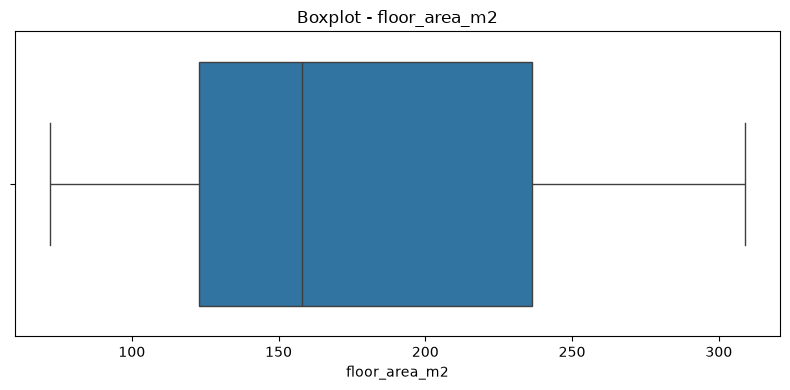

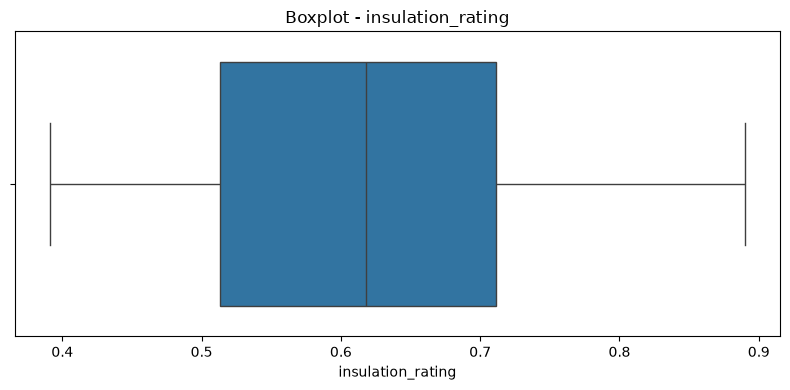

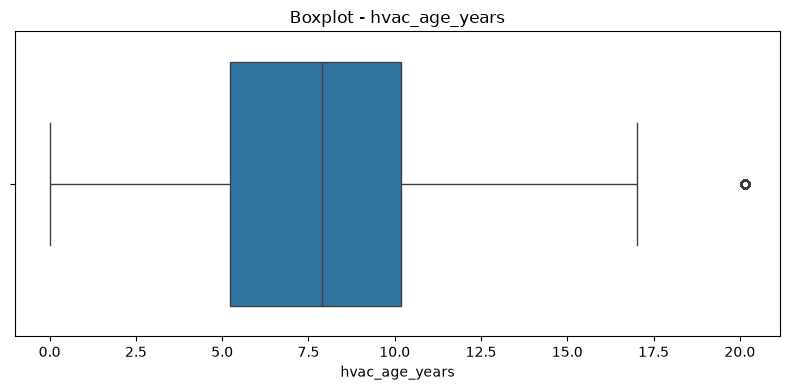

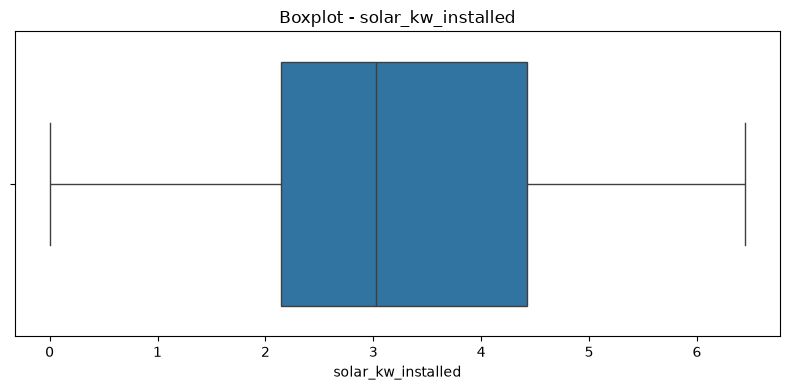

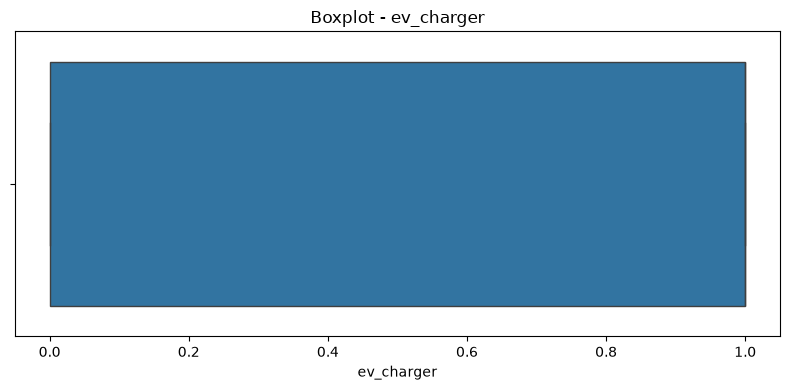

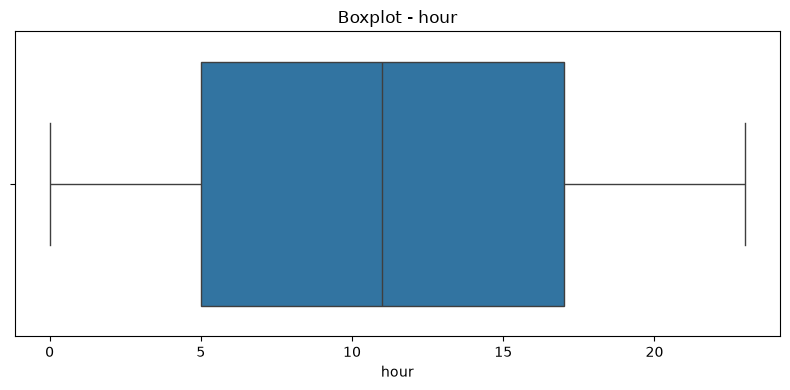

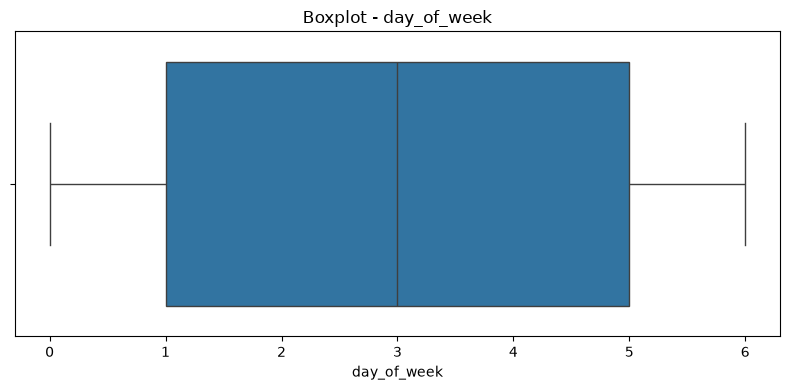

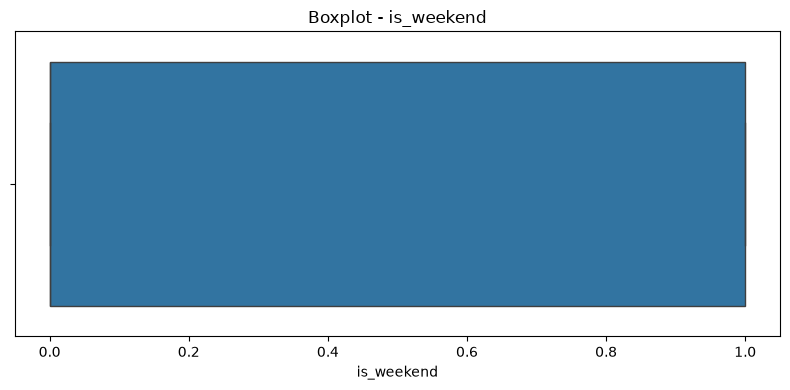

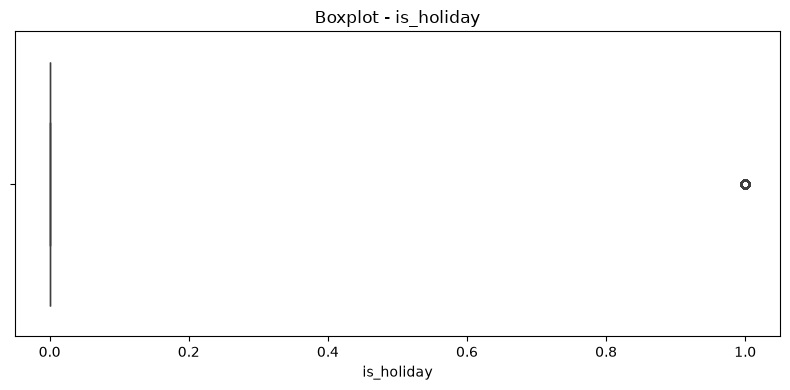

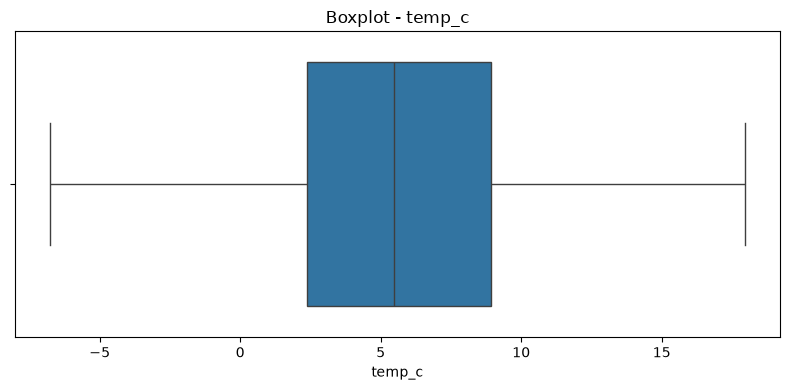

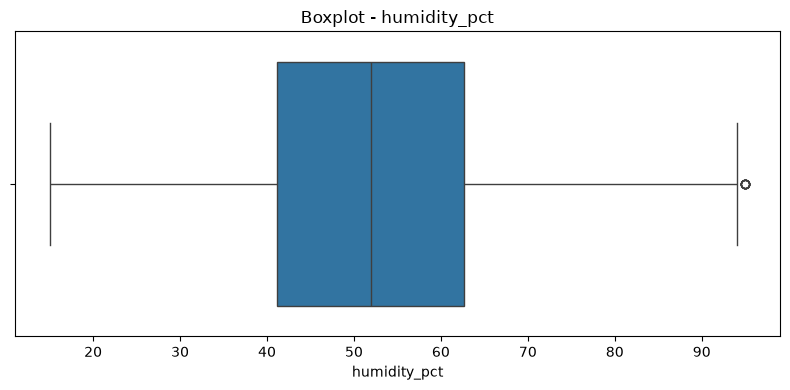

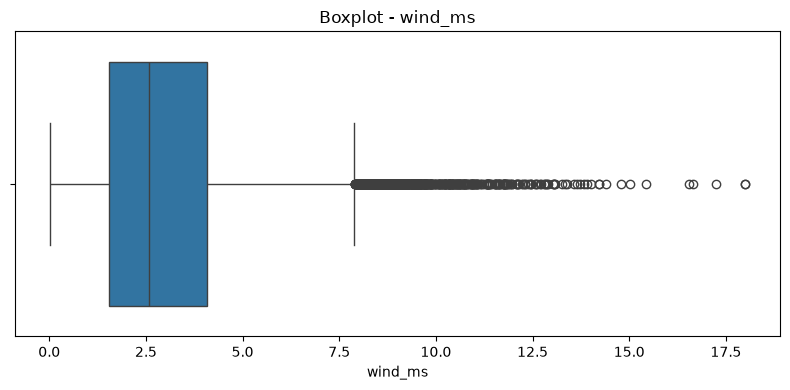

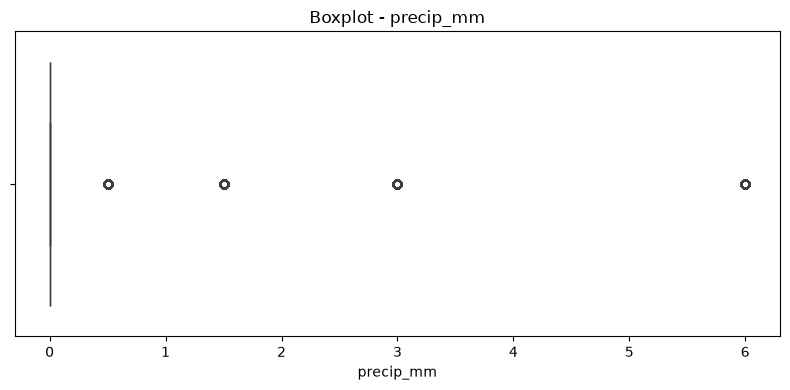

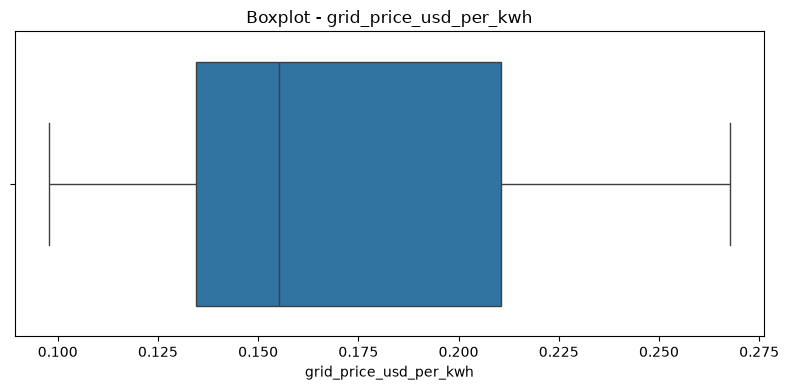

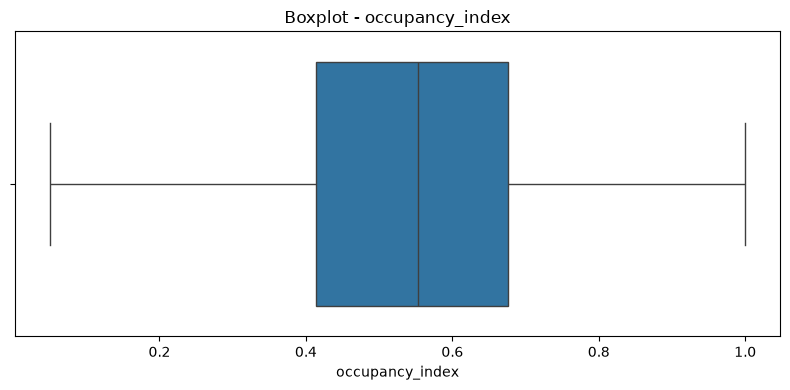

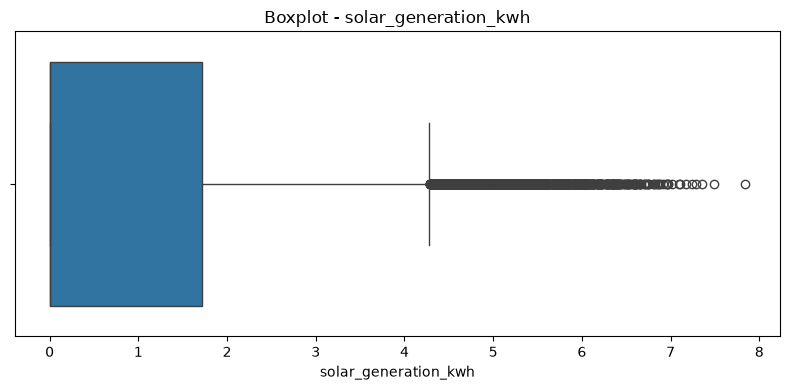

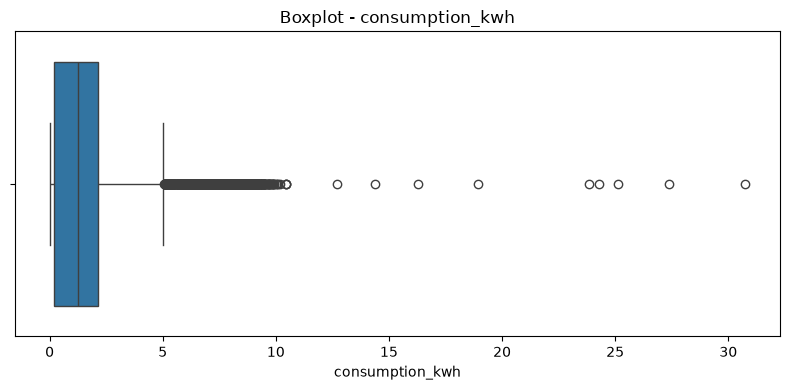

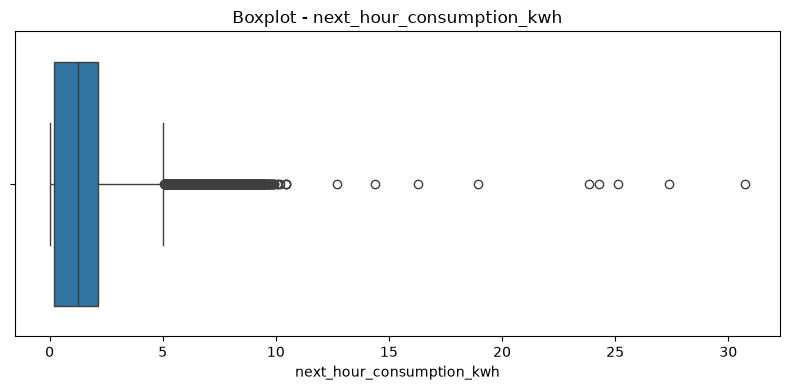

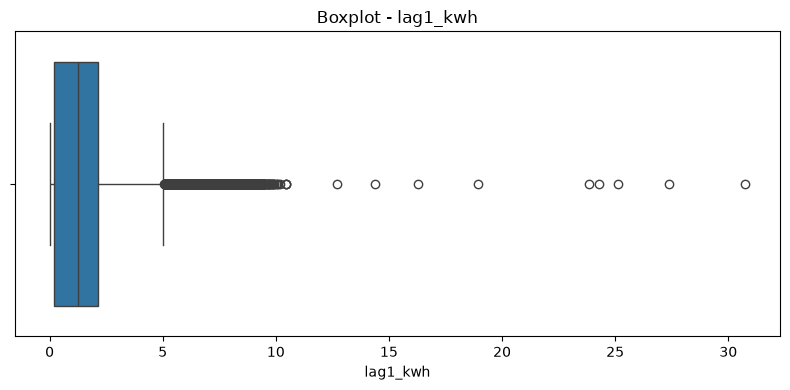

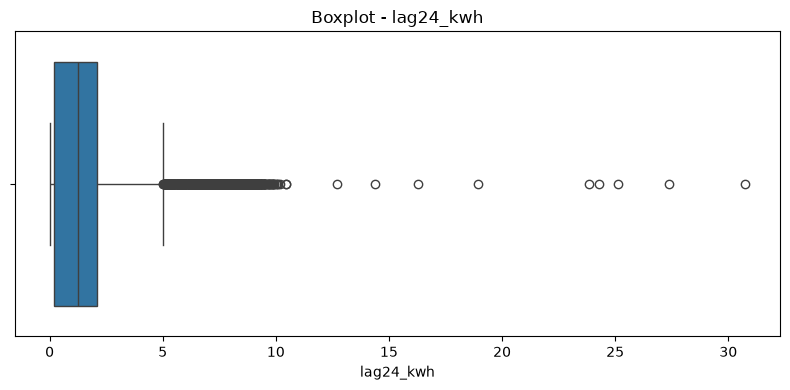

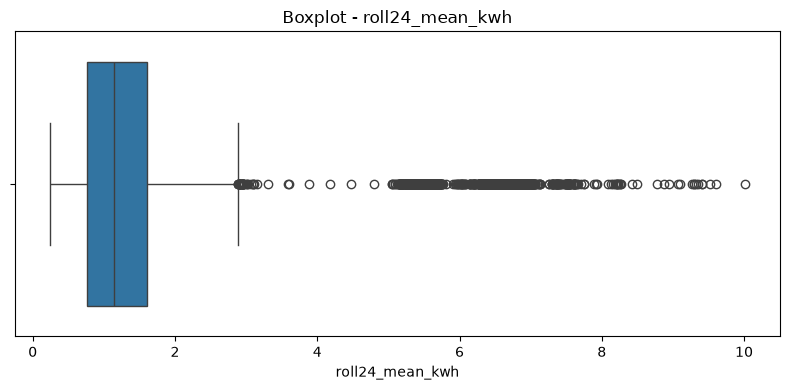

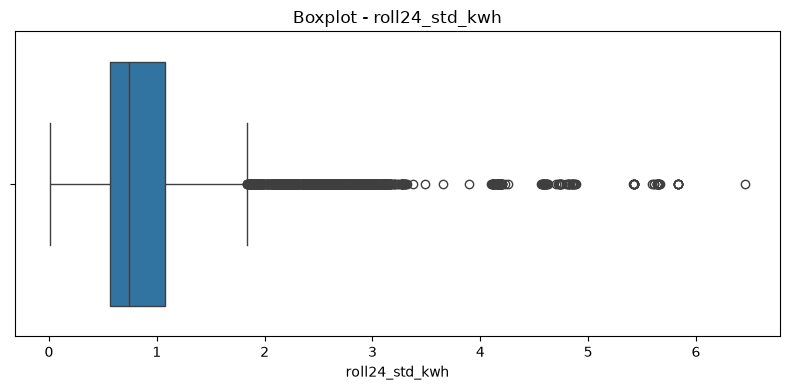

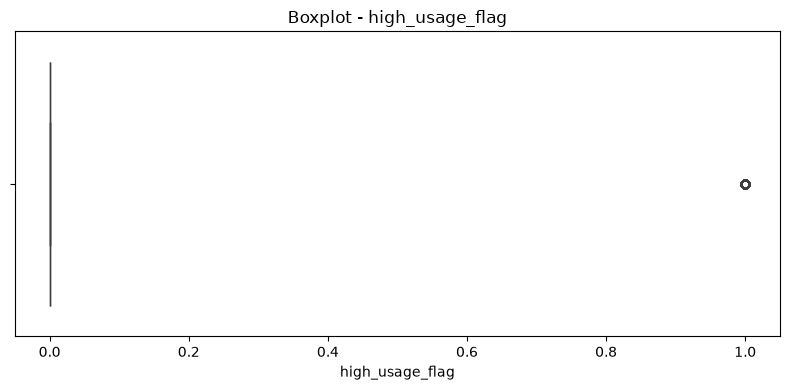

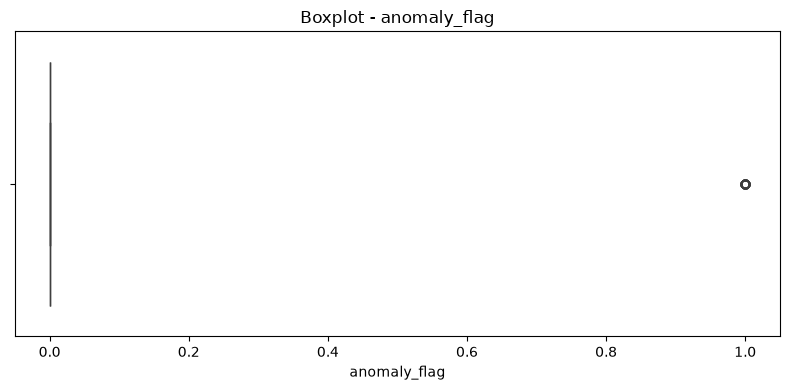

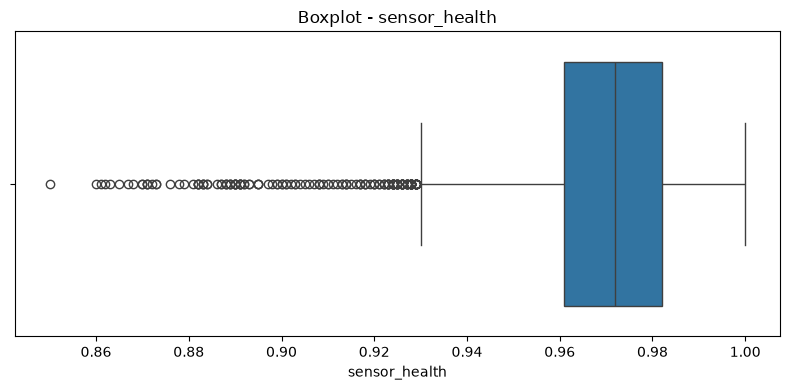

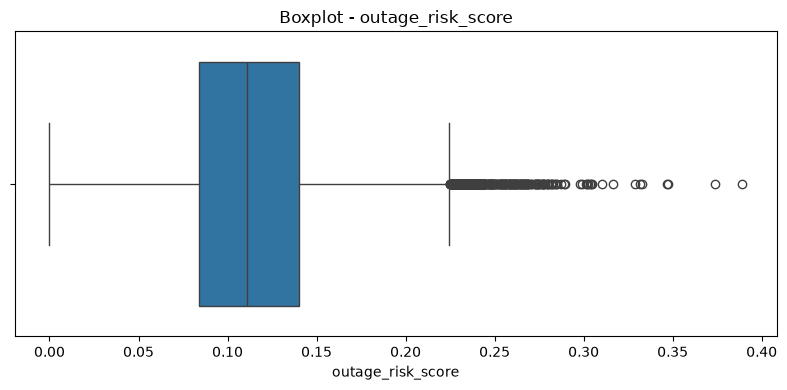

In [33]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.tight_layout()
    plt.show()

## 8. Correlation Analysis

الـ Correlation بتقيس العلاقة بين متغيرين رقميين.

القيمة بتكون من `-1` إلى `1`:

- قريبة من `1` → علاقة موجبة قوية.
- قريبة من `-1` → علاقة سالبة قوية.
- قريبة من `0` → مفيش علاقة خطية واضحة.

الـ Heatmap بتخلينا نشوف العلاقات بين الأعمدة كلها مرة واحدة.

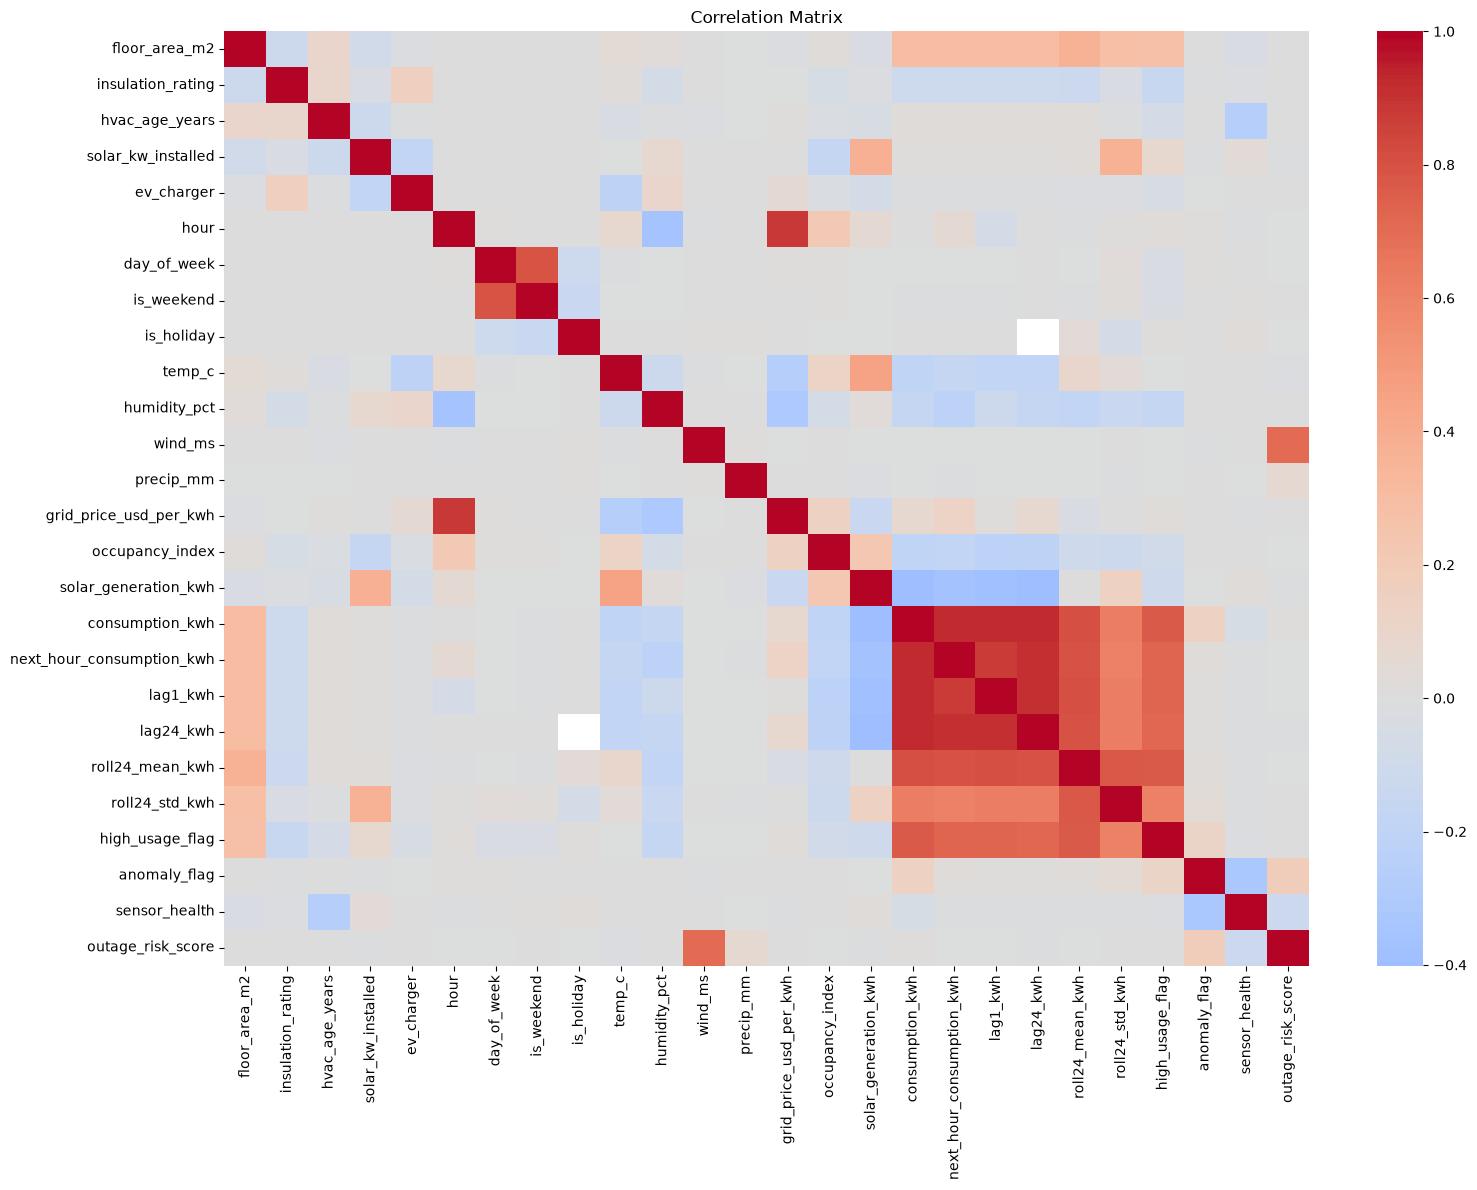

In [34]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Highly Correlated Features

هنا بنطلع أزواج الأعمدة اللي قيمة الـ correlation بينهم `0.80` أو أكتر في القيمة المطلقة.

الـ correlation العالية ممكن تشير إن في Features بتقدم معلومات متشابهة جدًا، وده ممكن نحتاج نراجعه وقت Feature Selection.

In [35]:
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = (
    corr_pairs.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: "Correlation"})
)

high_corr["Abs Correlation"] = high_corr["Correlation"].abs()

display(
    high_corr[high_corr["Abs Correlation"] >= 0.80]
    .sort_values("Abs Correlation", ascending=False)
)

,Feature 1,Feature 2,Correlation,Abs Correlation
435,consumption_kwh,lag24_kwh,0.927456,0.927456
434,consumption_kwh,lag1_kwh,0.922029,0.922029
433,consumption_kwh,next_hour_consumption_kwh,0.922029,0.922029
461,next_hour_consumption_kwh,lag24_kwh,0.910303,0.910303
487,lag1_kwh,lag24_kwh,0.909597,0.909597
143,hour,grid_price_usd_per_kwh,0.884828,0.884828
460,next_hour_consumption_kwh,lag1_kwh,0.875831,0.875831
488,lag1_kwh,roll24_mean_kwh,0.806343,0.806343
436,consumption_kwh,roll24_mean_kwh,0.805152,0.805152


## 9. Time-Based Feature Engineering

الـ `timestamp` غالبًا بيحتوي معلومات مفيدة عن الوقت.

بنحوله الأول إلى datetime باستخدام `pd.to_datetime()`.

بعد كده ممكن نستخرج:
- `month`
- `day`
- `year`

وللوقت الدوري زي الساعة ويوم الأسبوع بنستخدم **Cyclic Encoding**.

ليه؟

لأن الساعة 23 والساعة 0 قريبين من بعض زمنيًا، لكن لو استخدمنا الرقم نفسه ممكن المودل يشوفهم بعيدين جدًا.

عشان كده بنستخدم `sin` و`cos` لتمثيل الدورة بشكل أفضل.

In [36]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

if "month" not in df.columns:
    df["month"] = df["timestamp"].dt.month

if "day" not in df.columns:
    df["day"] = df["timestamp"].dt.day

if "year" not in df.columns:
    df["year"] = df["timestamp"].dt.year

if "hour" in df.columns:
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

if "day_of_week" in df.columns:
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df.head()

,meter_id,timestamp,region,building_type,floor_area_m2,insulation_rating,hvac_age_years,solar_kw_installed,ev_charger,hour,day_of_week,is_weekend,is_holiday,tariff_tier,temp_c,humidity_pct,wind_ms,precip_mm,grid_price_usd_per_kwh,occupancy_index,solar_generation_kwh,consumption_kwh,next_hour_consumption_kwh,lag1_kwh,lag24_kwh,roll24_mean_kwh,roll24_std_kwh,high_usage_flag,anomaly_flag,sensor_health,outage_risk_score,month,day,year,hour_sin,hour_cos,dow_sin,dow_cos
0,M001,2025-01-01 00:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,0,2,0,1,off_peak,0.41,44.0,2.73,0.0,0.1330,0.145,0.0,2.7074,2.5389,NaN,NaN,2.7074,NaN,0,0,0.973,0.1012,1,1,2025,0.000000,1.000000,0.974928,-0.222521
1,M001,2025-01-01 01:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,1,2,0,1,off_peak,1.34,53.5,3.18,0.0,0.1200,0.180,0.0,2.5389,2.6194,2.7074,NaN,2.6232,0.1191,0,0,0.979,0.1195,1,1,2025,0.258819,0.965926,0.974928,-0.222521
2,M001,2025-01-01 02:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,2,2,0,1,off_peak,1.22,55.9,4.64,0.0,0.1308,0.239,0.0,2.6194,2.3420,2.5389,NaN,2.6219,0.0843,0,0,0.940,0.1562,1,1,2025,0.500000,0.866025,0.974928,-0.222521
3,M001,2025-01-01 03:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,3,2,0,1,off_peak,3.03,61.0,3.02,0.5,0.1216,0.231,0.0,2.3420,2.6295,2.6194,NaN,2.5519,0.1560,0,0,0.943,0.1309,1,1,2025,0.707107,0.707107,0.974928,-0.222521
4,M001,2025-01-01 04:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,4,2,0,1,off_peak,1.36,65.8,4.45,0.0,0.1323,0.184,0.0,2.6295,2.2090,2.3420,NaN,2.5674,0.1394,0,0,0.995,0.1704,1,1,2025,0.866025,0.500000,0.974928,-0.222521


## 10. Missing Value Handling

بعد ما عرفنا أماكن الـ Missing Values، هنا بنعالجها.

للأعمدة الرقمية بنستخدم **median**.

الـ median أقل تأثرًا بالـ outliers من الـ mean.

للأعمدة categorical بنستخدم **mode**، يعني أكثر قيمة متكررة.

في النهاية بنحسب إجمالي الـ missing values المتبقية للتأكد إن مفيش قيم ناقصة.

In [37]:
numeric_cols_current = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols_current:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

categorical_cols_current = df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in categorical_cols_current:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


C:\Users\Ibrah\AppData\Local\Temp\ipykernel_27504\1163527583.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_current = df.select_dtypes(include=["object", "category"]).columns.tolist()


## 11. Remove Columns That Should Not Enter the Model Directly

الـ `timestamp` تم استخراج معلومات مفيدة منه، لذلك مش محتاجين ندخله كـ timestamp خام للمودل.

والـ `meter_id` مجرد Identifier، يعني بيميز العداد لكنه مش Feature لها معنى تنبؤي في حد ذاتها.

لذلك بنشيلهم من نسخة البيانات اللي هنجهزها للمودل، ونحتفظ بالداتا الأصلية في `df`.

In [38]:
drop_for_model = []

if "timestamp" in df.columns:
    drop_for_model.append("timestamp")

if "meter_id" in df.columns:
    drop_for_model.append("meter_id")

df_model = df.drop(columns=drop_for_model).copy()

print("Dropped from model input:", drop_for_model)
print("New shape:", df_model.shape)

Dropped from model input: ['timestamp', 'meter_id']
New shape: (20000, 36)


## 12. One-Hot Encoding

المودلز غالبًا مش بتفهم النصوص مباشرة.

لو عندنا عمود categorical مثل نوع أو فئة، بنستخدم **One-Hot Encoding** لتحويل الفئات لأعمدة رقمية.

`get_dummies()` بيعمل الأعمدة الجديدة.

`drop_first=True` بيشيل أول فئة لتقليل التكرار بين الأعمدة الناتجة.

In [39]:
categorical_cols_model = df_model.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns to encode:", categorical_cols_model)

df_encoded = pd.get_dummies(
    df_model,
    columns=categorical_cols_model,
    drop_first=True,
    dtype=int
)

print("Shape after One-Hot Encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns to encode: ['region', 'building_type', 'tariff_tier']
Shape after One-Hot Encoding: (20000, 41)


C:\Users\Ibrah\AppData\Local\Temp\ipykernel_27504\1354593982.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_model = df_model.select_dtypes(


,floor_area_m2,insulation_rating,hvac_age_years,solar_kw_installed,ev_charger,hour,day_of_week,is_weekend,is_holiday,temp_c,humidity_pct,wind_ms,precip_mm,grid_price_usd_per_kwh,occupancy_index,solar_generation_kwh,consumption_kwh,next_hour_consumption_kwh,lag1_kwh,lag24_kwh,roll24_mean_kwh,roll24_std_kwh,high_usage_flag,anomaly_flag,sensor_health,outage_risk_score,month,day,year,hour_sin,hour_cos,dow_sin,dow_cos,region_NE,region_SE,region_SW,region_W,building_type_industrial,building_type_residential,tariff_tier_off_peak,tariff_tier_on_peak
0,113,0.709966,16.486924,2.762723,1,0,2,0,1,0.41,44.0,2.73,0.0,0.1330,0.145,0.0,2.7074,2.5389,1.23525,1.2384,2.7074,0.7459,0,0,0.973,0.1012,1,1,2025,0.000000,1.000000,0.974928,-0.222521,0,0,0,1,0,0,1,0
1,113,0.709966,16.486924,2.762723,1,1,2,0,1,1.34,53.5,3.18,0.0,0.1200,0.180,0.0,2.5389,2.6194,2.70740,1.2384,2.6232,0.1191,0,0,0.979,0.1195,1,1,2025,0.258819,0.965926,0.974928,-0.222521,0,0,0,1,0,0,1,0
2,113,0.709966,16.486924,2.762723,1,2,2,0,1,1.22,55.9,4.64,0.0,0.1308,0.239,0.0,2.6194,2.3420,2.53890,1.2384,2.6219,0.0843,0,0,0.940,0.1562,1,1,2025,0.500000,0.866025,0.974928,-0.222521,0,0,0,1,0,0,1,0
3,113,0.709966,16.486924,2.762723,1,3,2,0,1,3.03,61.0,3.02,0.5,0.1216,0.231,0.0,2.3420,2.6295,2.61940,1.2384,2.5519,0.1560,0,0,0.943,0.1309,1,1,2025,0.707107,0.707107,0.974928,-0.222521,0,0,0,1,0,0,1,0
4,113,0.709966,16.486924,2.762723,1,4,2,0,1,1.36,65.8,4.45,0.0,0.1323,0.184,0.0,2.6295,2.2090,2.34200,1.2384,2.5674,0.1394,0,0,0.995,0.1704,1,1,2025,0.866025,0.500000,0.974928,-0.222521,0,0,0,1,0,0,1,0


## 13. Separate Features and Possible Targets

لسه مش هنختار target نهائي ولا هنبدأ Modeling.

إحنا بس بنشوف أي targets محتملة موجودة بعد الـ preprocessing.

بعد ما نحدد هدف المشروع، هنختار Target واحد ونفصل:

- `X` = الـ Features
- `y` = الـ Target

مثال:
`X = df_encoded.drop(columns=[TARGET])`
`y = df_encoded[TARGET]`

In [40]:

possible_targets = [
    "next_hour_consumption_kwh",
    "high_usage_flag",
    "anomaly_flag",
    "outage_risk_score"
]

available_targets = [col for col in possible_targets if col in df_encoded.columns]

print("Available possible targets:")
print(available_targets)


Available possible targets:
['next_hour_consumption_kwh', 'high_usage_flag', 'anomaly_flag', 'outage_risk_score']


## 14. Scaling

الـ Scaling بيخلي الـ numerical features على مقياس متقارب.

هنا بنستخدم `StandardScaler`.

الفكرة الأساسية:

`z = (x - mean) / standard deviation`

لكن مش كل الأعمدة محتاجة Scaling.

الأعمدة الثنائية الناتجة من One-Hot Encoding زي `0` و`1` بنسيبها كما هي.

والـ target كمان مش المفروض نعمله Scaling كجزء من الـ feature preprocessing.

In [41]:

X_prepared = df_encoded.copy()

binary_cols = [
    col for col in X_prepared.columns
    if X_prepared[col].dropna().isin([0, 1]).all()
]

possible_target_cols = [
    col for col in possible_targets
    if col in X_prepared.columns
]

scale_cols = [
    col for col in X_prepared.select_dtypes(include=np.number).columns
    if col not in binary_cols and col not in possible_target_cols
]

scaler = StandardScaler()

if scale_cols:
    X_prepared[scale_cols] = scaler.fit_transform(X_prepared[scale_cols])

print("Scaled columns:", scale_cols)
print("\nBinary columns not scaled:", binary_cols)

Scaled columns: ['floor_area_m2', 'insulation_rating', 'hvac_age_years', 'solar_kw_installed', 'hour', 'day_of_week', 'temp_c', 'humidity_pct', 'wind_ms', 'precip_mm', 'grid_price_usd_per_kwh', 'occupancy_index', 'solar_generation_kwh', 'consumption_kwh', 'lag1_kwh', 'lag24_kwh', 'roll24_mean_kwh', 'roll24_std_kwh', 'sensor_health', 'day', 'year', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

Binary columns not scaled: ['ev_charger', 'is_weekend', 'is_holiday', 'high_usage_flag', 'anomaly_flag', 'month', 'region_NE', 'region_SE', 'region_SW', 'region_W', 'building_type_industrial', 'building_type_residential', 'tariff_tier_off_peak', 'tariff_tier_on_peak']


## 15. Final Data Quality Check

في النهاية بنراجع الداتا بعد كل الخطوات.

بنشوف:
- الـ shape النهائي
- هل لسه في Missing Values؟
- هل لسه في Duplicate Rows؟
- أنواع البيانات
- أول كام صف

الهدف إننا نتأكد إن الداتا جاهزة كمرحلة preprocessing قبل ما ننتقل للـ train/test split والـ models.

**مهم:** في المشروع الحقيقي، الـ scaler والـ imputation والـ encoding الأفضل يتعملوا على بيانات التدريب فقط ثم نطبقهم على الـ test لتجنب Data Leakage.

In [42]:
print("Final shape:", X_prepared.shape)

print("\nRemaining missing values:")
print(X_prepared.isnull().sum().sum())

print("\nRemaining duplicate rows:")
print(X_prepared.duplicated().sum())

print("\nFinal data types:")
display(X_prepared.dtypes.value_counts())

display(X_prepared.head())

Final shape: (20000, 41)

Remaining missing values:
0

Remaining duplicate rows:
0

Final data types:


float64    27
int64      13
int32       1
Name: count, dtype: int64

,floor_area_m2,insulation_rating,hvac_age_years,solar_kw_installed,ev_charger,hour,day_of_week,is_weekend,is_holiday,temp_c,humidity_pct,wind_ms,precip_mm,grid_price_usd_per_kwh,occupancy_index,solar_generation_kwh,consumption_kwh,next_hour_consumption_kwh,lag1_kwh,lag24_kwh,roll24_mean_kwh,roll24_std_kwh,high_usage_flag,anomaly_flag,sensor_health,outage_risk_score,month,day,year,hour_sin,hour_cos,dow_sin,dow_cos,region_NE,region_SE,region_SW,region_W,building_type_industrial,building_type_residential,tariff_tier_off_peak,tariff_tier_on_peak
0,-0.9283,0.606711,1.882541,-0.229475,1,-1.657274,-0.508016,0,1,-1.117342,-0.511492,-0.160690,-0.281012,-0.852360,-1.780008,-0.657211,0.640963,2.5389,-0.178029,-0.171655,0.775593,-0.275243,0,0,0.118877,0.1012,1,-1.649817,0.0,-0.006590,1.424096,1.388893,-0.307372,0,0,0,1,0,0,1,0
1,-0.9283,0.606711,1.882541,-0.229475,1,-1.512154,-0.508016,0,1,-0.913564,0.120463,0.056543,-0.281012,-1.167447,-1.614722,-0.657211,0.547111,2.6194,0.642664,-0.171655,0.718075,-1.334894,0,0,0.494514,0.1195,1,-1.649817,0.0,0.359127,1.375864,1.388893,-0.307372,0,0,0,1,0,0,1,0
2,-0.9283,0.606711,1.882541,-0.229475,1,-1.367033,-0.508016,0,1,-0.939858,0.280115,0.761345,-0.281012,-0.905683,-1.336097,-0.657211,0.591948,2.3420,0.548728,-0.171655,0.717187,-1.393725,0,0,-1.947127,0.1562,1,-1.649817,0.0,0.699920,1.234456,1.388893,-0.307372,0,0,0,1,0,0,1,0
3,-0.9283,0.606711,1.882541,-0.229475,1,-1.221913,-0.508016,0,1,-0.543257,0.619375,-0.020695,0.215564,-1.128667,-1.373876,-0.657211,0.437440,2.6295,0.593606,-0.171655,0.669369,-1.272511,0,0,-1.759309,0.1309,1,-1.649817,0.0,0.992567,1.009508,1.388893,-0.307372,0,0,0,1,0,0,1,0
4,-0.9283,0.606711,1.882541,-0.229475,1,-1.076793,-0.508016,0,1,-0.909182,0.938678,0.669624,-0.281012,-0.869326,-1.595832,-0.657211,0.597574,2.2090,0.438961,-0.171655,0.679957,-1.300575,0,0,1.496212,0.1704,1,-1.649817,0.0,1.217122,0.716350,1.388893,-0.307372,0,0,0,1,0,0,1,0


## 16. Baseline Model — Logistic Regression

هنبني أول موديل تصنيف للتنبؤ بـ `anomaly_flag` (0 = طبيعي، 1 = شذوذ).

اخترنا الـ **Logistic Regression** كـ baseline لأنها بسيطة وسريعة وقابلة للتفسير، فبتدينا نقطة مرجعية نقارن بيها أي موديل أعقد بعد كده.

### خطوات الخلية

**1. التحقق من الـ Target**
بنطبع توزيع الـ classes ونسبة الـ anomalies. الرقم ده مهم لأنه بيحدد باقي قراراتنا — لو أقل من 20% تبقى الداتا **غير متوازنة (Imbalanced)** ومحتاجة تعامل خاص.

**2. فصل الـ Features ومنع الـ Data Leakage**
بنشيل:
- كل الـ targets المحتملة (مش الحالي بس) — لأنها مترابطة مع الشذوذ وهتدي الموديل إجابة جاهزة
- `meter_id` و `timestamp` — مجرد Identifiers مالهاش معنى تنبؤي
- الأعمدة الثابتة اللي قيمتها واحدة في كل الصفوف

**3. Time-Based Split**
الداتا زمنية، والتقسيم العشوائي بيحط صفوف من المستقبل في الـ Train فيطلع تقييم أحسن من الحقيقة. عشان كده بنرتّب بالوقت وناخد أقدم 80% للتدريب وأحدث 20% للاختبار — ده بيحاكي الواقع: تتدرب على اللي فات وتتنبأ باللي جاي.

**4. الـ Pipeline (Scaling + Model)**
حطينا الـ `StandardScaler` جوه `Pipeline` مع الموديل، فبيتعمل له `fit` على الـ Train بس و `transform` على الـ Test — ضمانة إن مفيش تسريب.

الـ Scaling بيتطبق على الأعمدة المستمرة فقط؛ الأعمدة الثنائية (0/1) الناتجة من الـ One-Hot Encoding بتتساب زي ما هي.

**5. `class_weight="balanced"`**
من غيرها، الموديل بيلاقي أسهل حل إنه يقول "طبيعي" لكل صف ويجيب Accuracy عالية من غير ما يتعلم حاجة. الإعداد ده بيدي وزن أكبر للـ class النادرة فبيجبره يتعلم النمط الحقيقي.

**6. `predict_proba` + Baseline**
بنحتفظ بالاحتمالات مش بالتصنيف بس، عشان نقدر نحسب ROC-AUC و PR-AUC ونضبط عتبة القرار بعدين.

والـ `DummyClassifier` بيقول "طبيعي" لكل صف — الـ Accuracy العالية بتاعته مع Recall صفر هي الدليل العملي إن الـ Accuracy لوحدها مقياس مضلل هنا.

In [48]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.2
SPLIT_STRATEGY = "time"          # "time" لو الداتا زمنية | "random" غير كده
target_col = "anomaly_flag"

# ---------- 1) التحقق من الـ Target ----------
assert target_col in df_encoded.columns, f"Target '{target_col}' not found"

y = df_encoded[target_col].astype(int)

print("Class distribution:")
print(y.value_counts().sort_index())
print(f"\nAnomaly rate = {y.mean():.4f}")
if y.mean() < 0.20:
    print(">> داتا غير متوازنة → Accuracy مقياس مضلل. هنعتمد على PR-AUC / Recall.")

# ---------- 2) الـ Features مع منع التسريب ----------
drop_cols = [col for col in possible_targets if col in df_encoded.columns]
for extra in ["timestamp", "meter_id"]:          # Identifiers مش Features
    if extra in df_encoded.columns:
        drop_cols.append(extra)

X = df_encoded.drop(columns=drop_cols)

# حذف الأعمدة الثابتة (قيمة واحدة) — مالهاش أي فائدة
const_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
if const_cols:
    X = X.drop(columns=const_cols)
    print("\nDropped constant columns:", const_cols)

print("Dropped from features:", drop_cols)
print("X shape:", X.shape)

# ---------- 3) التقسيم الصحيح (Time-based) ----------
if SPLIT_STRATEGY == "time" and "timestamp" in df.columns:
    order = np.argsort(df["timestamp"].values)
    cut = int(len(order) * (1 - TEST_SIZE))
    tr_idx, te_idx = order[:cut], order[cut:]

    X_train, X_test = X.iloc[tr_idx], X.iloc[te_idx]
    y_train, y_test = y.iloc[tr_idx], y.iloc[te_idx]

    print("\nSplit: TIME-BASED (تدريب على الماضي، اختبار على المستقبل)")
    print("  Train:", df["timestamp"].iloc[tr_idx].min(), "->", df["timestamp"].iloc[tr_idx].max())
    print("  Test :", df["timestamp"].iloc[te_idx].min(), "->", df["timestamp"].iloc[te_idx].max())
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    print("\nSplit: STRATIFIED RANDOM")

print("Train:", X_train.shape, "| anomaly rate:", round(y_train.mean(), 4))
print("Test :", X_test.shape,  "| anomaly rate:", round(y_test.mean(), 4))

# ---------- 4) تحديد الأعمدة المستمرة والثنائية (فحص آمن) ----------
def is_binary(s: pd.Series) -> bool:
    """فحص آمن: مش بيرجع True لعمود فاضي أو كله NaN."""
    v = s.dropna()
    if v.empty:
        return False
    return set(np.unique(v)).issubset({0, 1, 0.0, 1.0, True, False})

binary_cols = [c for c in X_train.columns if is_binary(X_train[c])]
cont_cols   = [c for c in X_train.columns if c not in binary_cols]
print(f"\nContinuous: {len(cont_cols)} | Binary (no scaling): {len(binary_cols)}")

# ---------- 5) الـ Pipeline: Scaling + Model ----------
preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), cont_cols),
        ("pass",  "passthrough",    binary_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

logreg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        solver="liblinear",
        C=1.0,
        class_weight="balanced",     # معالجة عدم التوازن
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

logreg.fit(X_train, y_train)

# احتمالات مش تصنيف بس
y_proba = logreg.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

print("\nModel trained. n_iter_ =", logreg.named_steps["clf"].n_iter_)

# ---------- 6) Baseline للمقارنة ----------
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE).fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print(f"\nDummy (بيقول 0 دايمًا): accuracy = {(dummy_pred == y_test).mean():.4f} | recall = 0.0000")
print(">> Accuracy عالية مع Recall صفر — عشان كده Accuracy لوحدها مقياس فاشل هنا.")

Class distribution:
anomaly_flag
0    19912
1       88
Name: count, dtype: int64

Anomaly rate = 0.0044
>> داتا غير متوازنة → Accuracy مقياس مضلل. هنعتمد على PR-AUC / Recall.

Dropped constant columns: ['month', 'year']
Dropped from features: ['next_hour_consumption_kwh', 'high_usage_flag', 'anomaly_flag', 'outage_risk_score']
X shape: (20000, 35)

Split: TIME-BASED (تدريب على الماضي، اختبار على المستقبل)
  Train: 2025-01-01 00:00:00 -> 2025-01-17 15:00:00
  Test : 2025-01-17 16:00:00 -> 2025-01-21 19:00:00
Train: (16000, 35) | anomaly rate: 0.0041
Test : (4000, 35) | anomaly rate: 0.0058

Continuous: 24 | Binary (no scaling): 11

Model trained. n_iter_ = [11]

Dummy (بيقول 0 دايمًا): accuracy = 0.9942 | recall = 0.0000
>> Accuracy عالية مع Recall صفر — عشان كده Accuracy لوحدها مقياس فاشل هنا.


## 17. Model Evaluation — تقييم الموديل

مع الداتا غير المتوازنة، اختيار المقياس الغلط ممكن يخليك تفتكر إن موديل فاشل ناجح. عشان كده بنستخدم مجموعة مقاييس مكمّلة لبعض.

---

### 1. الـ Confusion Matrix — أساس كل حاجة

كل المقاييس بتتحسب من الجدول ده:

| | الموديل قال طبيعي | الموديل قال شذوذ |
|---|---|---|
| **الحقيقة طبيعي** | True Negative (TN) | False Positive (FP) |
| **الحقيقة شذوذ** | False Negative (FN) | True Positive (TP) |

- **TP** — شذوذ حقيقي والموديل مسكه
- **TN** — صف طبيعي والموديل قال عليه طبيعي
- **FP** — إنذار كاذب: بعتنا فني يكشف على عدّاد سليم. مكلّف لكنه مش خطير
- **FN** — **الخانة الأخطر**: عطل حقيقي عدّى من غير ما حد ياخد باله

في سياق شبكة الكهرباء، الـ FN أغلى بكتير من الـ FP.

---

### 2. Accuracy — المقياس المضلل

$$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$

نسبة اللي الموديل جابه صح من كل حاجة.

**المشكلة:** لو الـ anomalies 5% بس، موديل بيقول "طبيعي" لكل صف بياخد 95% Accuracy وهو مالوش أي قيمة عملية.

المقارنة مع الـ `DummyClassifier` في الخلية السابقة بتوضح ده عمليًا: ممكن الـ Dummy يتفوق على موديلك في الـ Accuracy وهو مش بيتعلم حاجة خالص.

**الخلاصة:** الـ Accuracy هنا بتقيس نسبة الـ classes مش شطارة الموديل.

---

### 3. Recall — أهم مقياس في كشف الشذوذ

$$ \text{Recall} = \frac{TP}{TP + FN} $$

من كل الشذوذ الحقيقي الموجود، الموديل مسك كام منه؟

ده المقياس الأهم في مشروعنا، لأن العطل اللي بيفوت من غير كشف ممكن يتحول لانقطاع أو خسارة حقيقية.

---

### 4. Precision — دقة الإنذارات

$$ \text{Precision} = \frac{TP}{TP + FP} $$

من كل مرة الموديل أعلن شذوذ، كام مرة كان صح؟

Precision واطية معناها إنذارات كاذبة كتير، وده بيستهلك موارد الصيانة ويقلل الثقة في النظام.

---

### 5. التوازن بين Precision و Recall

المقياسين بيتحركوا في **اتجاهين متضادين** دايمًا:

- عايز تمسك كل شذوذ؟ أعلن شذوذ على أي حاجة مشبوهة → Recall ↑ و Precision ↓
- عايز إنذاراتك تكون دقيقة؟ ما تعلنش إلا لما تكون واثق → Precision ↑ و Recall ↓

مفيش إجابة صحيحة مطلقة — القرار بيعتمد على تكلفة كل نوع خطأ في السياق بتاعك.

---

### 6. F1-Score — التوازن بينهم

$$ F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

استخدمنا **المتوسط التوافقي (Harmonic Mean)** مش المتوسط الحسابي عشان يعاقب عدم التوازن بشدة.

مثال: لو Precision = 1.0 و Recall = 0.0، المتوسط الحسابي بيدي 0.5 (مضلل تمامًا)، لكن الـ F1 بيدي **صفر**.

يعني مينفعش تغش الـ F1 بتحسين ناحية واحدة على حساب التانية.

---

### 7. ROC-AUC — جودة الترتيب

الـ ROC Curve بيرسم العلاقة بين **True Positive Rate** و **False Positive Rate** عند كل العتبات الممكنة.

الـ **AUC** (المساحة تحت المنحنى) بتجاوب على السؤال: لو خدت صف شذوذ عشوائي وصف طبيعي عشوائي، إيه احتمال إن الموديل يدي الشذوذ احتمال أعلى؟

- `0.5` → عشوائي تمامًا (زي رمي عملة)
- `0.7 – 0.8` → مقبول
- `0.8 – 0.9` → كويس
- `0.9+` → ممتاز

**الميزة:** مستقل عن العتبة تمامًا، بيقيس جودة الاحتمالات نفسها.

**العيب:** بيبقى متفائل شوية مع الداتا غير المتوازنة، لأن عدد الـ TN الكبير بيضخّمه.

---

### 8. PR-AUC — المقياس الأصدق هنا

المساحة تحت منحنى **Precision-Recall**. بيركّز على الـ positive class (الشذوذ) بس، ومش بيتأثر بكتلة الـ True Negatives.

**نقطة مهمة جدًا:** الرقم ده مالوش معنى لوحده، لازم يتقارن بالـ baseline:

$$ \text{PR-AUC}_{\text{عشوائي}} = \text{نسبة الـ positives في الداتا} $$

يعني لو الـ anomalies 5%، الموديل العشوائي بياخد PR-AUC ≈ 0.05. موديلك لازم يكون **أعلى من الرقم ده بوضوح**، وإلا فهو مش بيتعلم أي إشارة حقيقية — حتى لو الـ Accuracy 95%.

الكود بيطبع المقارنة دي تلقائيًا.

---

### 9. ضبط الـ Threshold — خطوة أساسية مش رفاهية

الـ `predict()` بتستخدم عتبة `0.5`، لكن الرقم ده مجرد **قيمة افتراضية** مش قاعدة رياضية.

في كشف الشذوذ، تكلفة الـ **False Negative** (عطل فات) أعلى بكتير من تكلفة الـ **False Positive** (كشف زيادة). فمنطقيًا نخفّض العتبة عشان نمسك شذوذ أكتر، حتى لو زودنا الإنذارات الكاذبة.

الكود بيحسب المقاييس عند **كل العتبات الممكنة** وبيطلع:

1. العتبة اللي بتعظّم الـ **F1** — أفضل توازن عام
2. العتبة اللي بتوصل لـ **Recall ≥ 80%** بأعلى Precision ممكنة — لو الأولوية إننا منفوّتش أعطال

الجدول في الآخر بيقارن الأداء عند `0.5` مقابل العتبة المضبوطة. التحسن اللي بيظهر هنا بيجي **من غير أي تغيير في الموديل نفسه** — مجرد تغيير نقطة القرار.

---

### 10. الرسومات الثلاثة

- **Confusion Matrix** — بالعتبة المضبوطة. ركّز على خانة الـ False Negatives
- **ROC Curve** — كل ما المنحنى بعيد عن الخط القُطري كل ما الموديل أحسن
- **Precision-Recall Curve** — الخط الأفقي المتقطع هو أداء الموديل العشوائي، ومنحناك لازم يكون فوقه بوضوح. النقطة الحمرا هي العتبة اللي اخترناها

---

### 11. قراءة النتيجة

| الملاحظة | التفسير |
|---|---|
| PR-AUC قريبة من نسبة الـ anomalies | الموديل مش بيتعلم — العلاقة غالبًا غير خطية |
| Recall عالي و Precision واطي | طبيعي مع `class_weight="balanced"` — ارفع العتبة لو الإنذارات كتير |
| ROC-AUC كويس و PR-AUC ضعيف | الموديل بيرتّب صح لكن بيصعب عليه الفصل الحاسم |
| كل المقاييس ضعيفة | محتاج features أقوى أو موديل غير خطي |

**الخطوة الجاية:** مقارنة الـ baseline ده بموديلات أعقد زي `RandomForest` أو `XGBoost`. لو الفرق كبير، معناها إن العلاقة غير خطية والـ Logistic Regression مش قادرة تلتقطها.

كمان مفيد مراجعة صفوف الـ **False Negatives** يدويًا — الأنماط المشتركة بينهم بتقولك إيه بالظبط اللي الموديل عاجز يشوفه.

=== Model Performance (threshold = 0.5) ===


,Score
Accuracy,0.9958
Precision,0.5750
Recall,1.0000
F1-Score,0.7302
ROC-AUC,0.9999
PR-AUC,0.9898


Random-model PR-AUC = 0.0057
>> الموديل بيضيف قيمة حقيقية فوق العشوائي.

=== Detailed Classification Report ===
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00      3977
 Anomaly (1)       0.57      1.00      0.73        23

    accuracy                           1.00      4000
   macro avg       0.79      1.00      0.86      4000
weighted avg       1.00      1.00      1.00      4000

أفضل threshold للـ F1 = 0.9919
  Precision = 1.0000 | Recall = 0.9130 | F1 = 0.9545
لو عايز Recall >= 0.8: threshold = 0.9919 | Precision = 1.0000



,Threshold 0.5,Tuned (0.992)
Precision,0.5750,1.0000
Recall,1.0000,0.9130
F1,0.7302,0.9545


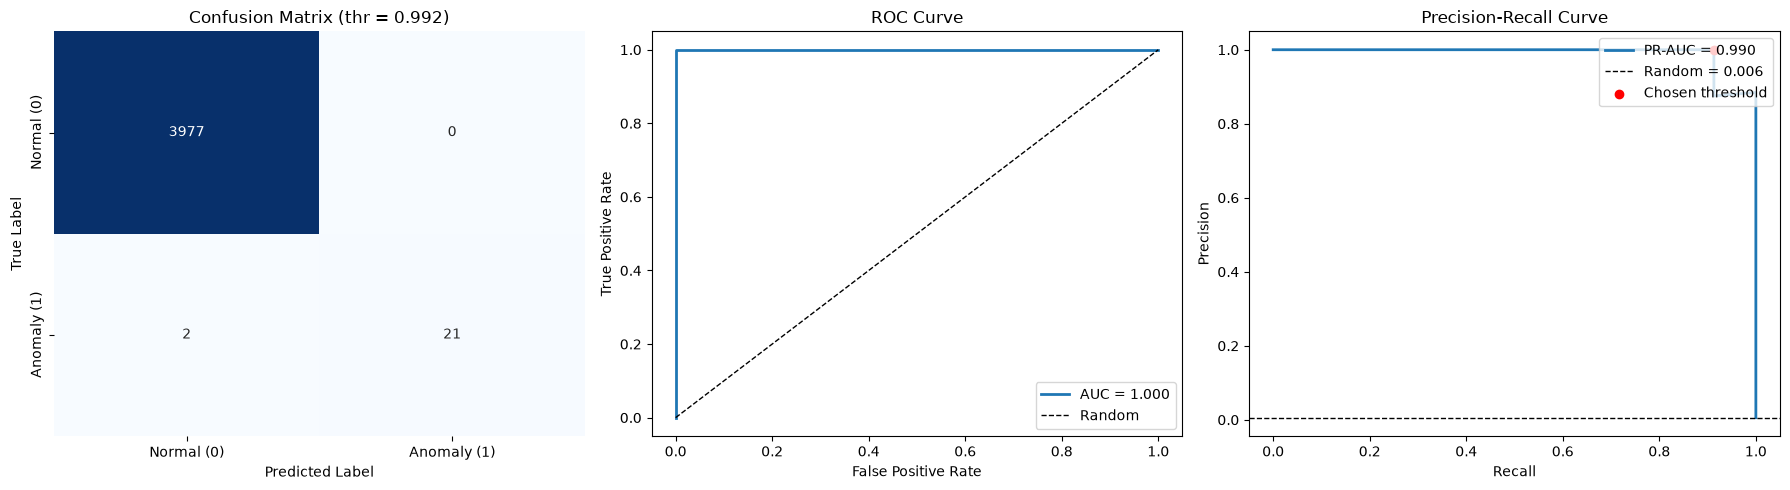

True Negatives : 3977
False Positives: 0   (إنذار كاذب)
False Negatives: 2   (شذوذ فات علينا — الأخطر)
True Positives : 21


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve
)

# ---------- 1) المقاييس ----------
metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall":    recall_score(y_test, y_pred, zero_division=0),
    "F1-Score":  f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC":   roc_auc_score(y_test, y_proba),
    "PR-AUC":    average_precision_score(y_test, y_proba),
}

print("=== Model Performance (threshold = 0.5) ===")
display(pd.DataFrame(metrics, index=["Score"]).T.round(4))

baseline_pr = y_test.mean()
print(f"Random-model PR-AUC = {baseline_pr:.4f}")
if metrics["PR-AUC"] > baseline_pr * 1.5:
    print(">> الموديل بيضيف قيمة حقيقية فوق العشوائي.")
else:
    print(">> تحذير: الـ PR-AUC قريبة من العشوائي — الموديل تقريبًا مش بيتعلم.")

print("\n=== Detailed Classification Report ===")
print(classification_report(
    y_test, y_pred,
    labels=[0, 1],
    target_names=["Normal (0)", "Anomaly (1)"],
    zero_division=0
))

# ---------- 2) ضبط الـ Threshold ----------
prec, rec, thr = precision_recall_curve(y_test, y_proba)
f1s = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)

best_i = int(np.nanargmax(f1s[:-1]))
best_thr = float(thr[best_i])

print(f"أفضل threshold للـ F1 = {best_thr:.4f}")
print(f"  Precision = {prec[best_i]:.4f} | Recall = {rec[best_i]:.4f} | F1 = {f1s[best_i]:.4f}")

TARGET_RECALL = 0.80
ok = np.where(rec[:-1] >= TARGET_RECALL)[0]
if len(ok):
    j = ok[np.argmax(prec[:-1][ok])]
    print(f"لو عايز Recall >= {TARGET_RECALL}: threshold = {thr[j]:.4f} | Precision = {prec[j]:.4f}")

y_pred_tuned = (y_proba >= best_thr).astype(int)

comparison = pd.DataFrame({
    "Threshold 0.5": [
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)],
    f"Tuned ({best_thr:.3f})": [
        precision_score(y_test, y_pred_tuned, zero_division=0),
        recall_score(y_test, y_pred_tuned, zero_division=0),
        f1_score(y_test, y_pred_tuned, zero_division=0)],
}, index=["Precision", "Recall", "F1"])

print()
display(comparison.round(4))

# ---------- 3) الرسومات ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred_tuned, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Normal (0)", "Anomaly (1)"],
            yticklabels=["Normal (0)", "Anomaly (1)"])
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].set_title(f"Confusion Matrix (thr = {best_thr:.3f})")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {metrics['ROC-AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

axes[2].plot(rec, prec, lw=2, label=f"PR-AUC = {metrics['PR-AUC']:.3f}")
axes[2].axhline(baseline_pr, color="k", ls="--", lw=1, label=f"Random = {baseline_pr:.3f}")
axes[2].scatter(rec[best_i], prec[best_i], color="red", zorder=5, label="Chosen threshold")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}   (إنذار كاذب)")
print(f"False Negatives: {fn}   (شذوذ فات علينا — الأخطر)")
print(f"True Positives : {tp}")

# 18. Ridge Regression — Next Hour Electricity Consumption Prediction

## Goal
Predict `next_hour_consumption_kwh` using information that is available **before the next hour**.

### Fixes included
- Leakage prevention
- Chronological time-series split (no random split)
- Scaling fitted on training data only
- Ridge `alpha` tuning with `TimeSeriesSplit`
- Training vs Test metrics for overfitting check
- MAE, MSE, RMSE and R²
- Actual vs Predicted plot
- Prediction error distribution
- Residual analysis


In [50]:
# ==============================
# 1. Prepare data and target
# ==============================

target = "next_hour_consumption_kwh"

# Work on a copy
model_df = df.copy()

# Sort chronologically BEFORE splitting
model_df["timestamp"] = pd.to_datetime(model_df["timestamp"], errors="coerce")
model_df = model_df.sort_values("timestamp").reset_index(drop=True)

# Remove rows where target/timestamp is unavailable
model_df = model_df.dropna(subset=[target, "timestamp"]).reset_index(drop=True)

print("Data shape:", model_df.shape)
print("Target:", target)
print("\nTarget statistics:")
print(model_df[target].describe())


Data shape: (20000, 38)
Target: next_hour_consumption_kwh

Target statistics:
count    20000.000000
mean         1.554513
std          1.792806
min          0.000000
25%          0.182725
50%          1.236050
75%          2.116750
max         30.747700
Name: next_hour_consumption_kwh, dtype: float64


In [51]:
# ==============================
# 2. Leakage-safe feature selection
# ==============================

# We predict the NEXT hour.
# Therefore, we must not use columns that directly contain future information
# or targets from other prediction tasks.

drop_cols = [
    target,
    "timestamp",
    "meter_id",

    # Future/target-derived fields from other tasks
    "high_usage_flag",
    "anomaly_flag",
    "outage_risk_score",
]

drop_cols = [c for c in drop_cols if c in model_df.columns]

X_raw = model_df.drop(columns=drop_cols)
y = model_df[target]

# Remove any remaining non-numeric columns.
# Categorical columns will be one-hot encoded below.
categorical_cols = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_raw.select_dtypes(include=["number", "bool"]).columns.tolist()

print("Categorical features:", categorical_cols)
print("Numeric features:", len(numeric_cols))
print("Total raw features:", X_raw.shape[1])

Categorical features: ['region', 'building_type', 'tariff_tier']
Numeric features: 29
Total raw features: 32


C:\Users\Ibrah\AppData\Local\Temp\ipykernel_27504\1384416782.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()


In [52]:
# ==============================
# 3. Chronological Train / Test Split
# ==============================

# IMPORTANT:
# No random_state / shuffle here.
# The model learns from the past and is tested on the future.

split_index = int(len(X_raw) * 0.80)

X_train_raw = X_raw.iloc[:split_index].copy()
X_test_raw  = X_raw.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test  = y.iloc[split_index:].copy()

print("Training rows:", len(X_train_raw))
print("Testing rows :", len(X_test_raw))

print("\nTraining period:")
print(model_df["timestamp"].iloc[0], "→", model_df["timestamp"].iloc[split_index - 1])

print("\nTesting period:")
print(model_df["timestamp"].iloc[split_index], "→", model_df["timestamp"].iloc[-1])

Training rows: 16000
Testing rows : 4000

Training period:
2025-01-01 00:00:00 → 2025-01-17 15:00:00

Testing period:
2025-01-17 16:00:00 → 2025-01-21 19:00:00


In [53]:
# ==============================
# 4. Preprocessing Pipeline
# ==============================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = X_train_raw.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# Fit ONLY on training data
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print("Processed train shape:", X_train.shape)
print("Processed test shape :", X_test.shape)


Processed train shape: (16000, 40)
Processed test shape : (4000, 40)


C:\Users\Ibrah\AppData\Local\Temp\ipykernel_27504\2297424489.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()


In [54]:
# ==============================
# 5. Ridge + Alpha Tuning
# ==============================

from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

ridge_pipeline = Pipeline([
    ("ridge", Ridge())
])

# TimeSeriesSplit preserves chronological order during tuning.
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best alpha:", grid_search.best_params_["ridge__alpha"])
print("Best CV RMSE:", -grid_search.best_score_)


Best alpha: 100
Best CV RMSE: 0.56895058595964


In [55]:
# ==============================
# 6. Predictions
# ==============================

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print("Predictions generated successfully.")


Predictions generated successfully.


In [56]:
# ==============================
# 7. Evaluation Metrics
# ==============================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

train_mae, train_mse, train_rmse, train_r2 = regression_metrics(y_train, y_train_pred)
test_mae, test_mse, test_rmse, test_r2 = regression_metrics(y_test, y_test_pred)

results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Training": [train_mae, train_mse, train_rmse, train_r2],
    "Testing": [test_mae, test_mse, test_rmse, test_r2]
})

display(results)


,Metric,Training,Testing
0,MAE,0.316982,0.331043
1,MSE,0.342115,0.311287
2,RMSE,0.584906,0.557931
3,R²,0.894616,0.899077


In [57]:
# ==============================
# 8. Overfitting Check
# ==============================

rmse_gap = test_rmse - train_rmse
r2_gap = train_r2 - test_r2

print("===== Overfitting Check =====")
print(f"Train RMSE : {train_rmse:.4f}")
print(f"Test RMSE  : {test_rmse:.4f}")
print(f"RMSE Gap   : {rmse_gap:.4f}")

print(f"\nTrain R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")
print(f"R² Gap    : {r2_gap:.4f}")

if r2_gap < 0.05:
    print("\nResult: No strong evidence of overfitting.")
elif r2_gap < 0.10:
    print("\nResult: Mild possible overfitting.")
else:
    print("\nResult: Possible overfitting — investigate features and regularization.")


===== Overfitting Check =====
Train RMSE : 0.5849
Test RMSE  : 0.5579
RMSE Gap   : -0.0270

Train R²  : 0.8946
Test R²   : 0.8991
R² Gap    : -0.0045

Result: No strong evidence of overfitting.


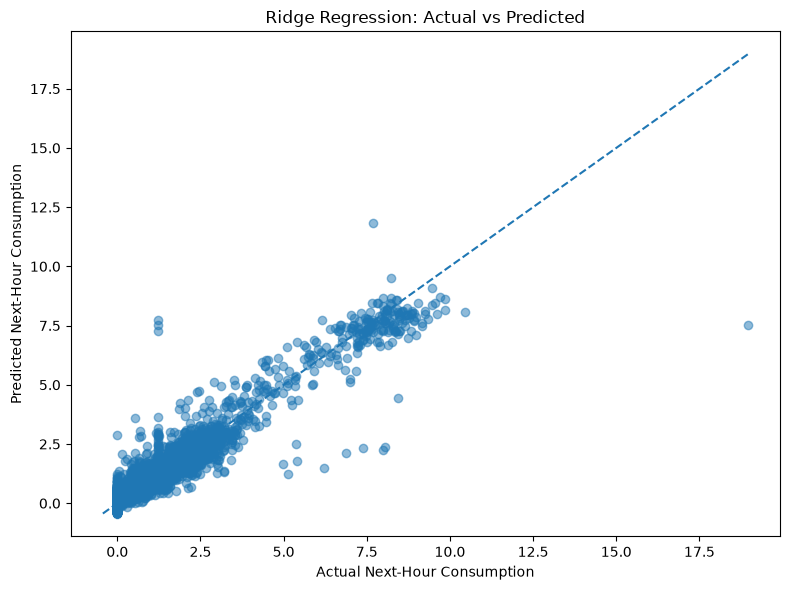

In [58]:
# ==============================
# 9. Actual vs Predicted
# ==============================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual Next-Hour Consumption")
plt.ylabel("Predicted Next-Hour Consumption")
plt.title("Ridge Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()


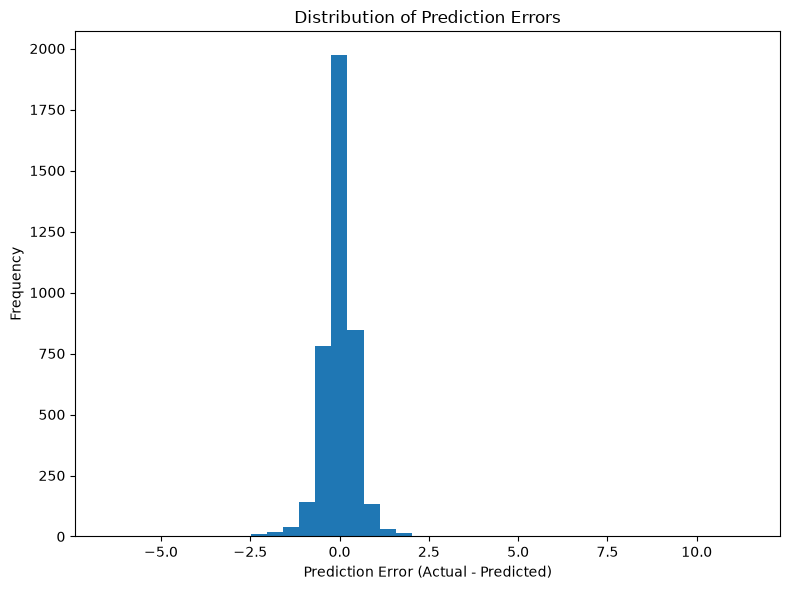

Mean Error: -0.001801867669838499
Median Error: 0.014892449607617597


In [59]:
# ==============================
# 10. Prediction Error Analysis
# ==============================

errors = y_test - y_test_pred

plt.figure(figsize=(8, 6))
plt.hist(errors, bins=40)
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.tight_layout()
plt.show()

print("Mean Error:", errors.mean())
print("Median Error:", errors.median())


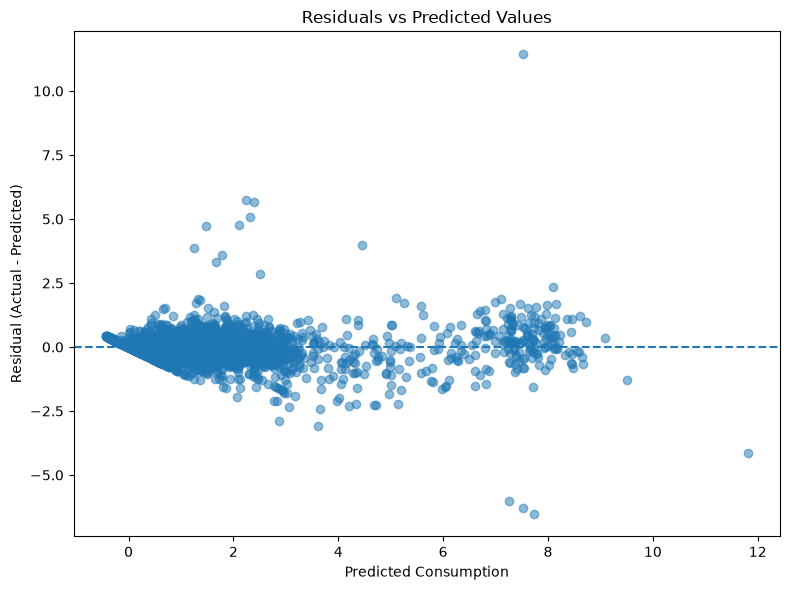

In [60]:
# ==============================
# 11. Residuals vs Predictions
# ==============================

plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, errors, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Consumption")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()


In [61]:
# ==============================
# 12. Prediction Sample
# ==============================

comparison = pd.DataFrame({
    "Actual Consumption": y_test.values,
    "Predicted Consumption": y_test_pred,
    "Absolute Error": np.abs(y_test.values - y_test_pred)
})

display(comparison.head(20))


,Actual Consumption,Predicted Consumption,Absolute Error
0,1.0211,1.209931,0.188831
1,3.3462,2.712856,0.633344
2,0.1650,0.718120,0.553120
3,0.5300,0.625540,0.095540
4,0.1773,0.611462,0.434162
5,1.5346,1.267620,0.266980
6,0.0000,0.568626,0.568626
7,1.9304,1.886776,0.043624
8,1.2663,0.964854,0.301446
9,0.0000,0.615789,0.615789


# 19.Final Ridge Regression Summary

### Target
`next_hour_consumption_kwh`

### Main fixes
1. **No random train/test split** → chronological split.
2. **No preprocessing leakage** → imputer, encoder and scaler are fitted on training data only.
3. **Alpha tuning** → tested `[0.01, 0.1, 1, 10, 100]` with `TimeSeriesSplit`.
4. **Overfitting check** → Training vs Testing RMSE and R².
5. **Leakage prevention** → removed future/target-derived columns such as `high_usage_flag`, `anomaly_flag`, and `outage_risk_score`.
6. **Error analysis** → prediction errors + residual plot.

> Note: `consumption_kwh`, `lag1_kwh`, `lag24_kwh`, and rolling features are retained because they can be valid predictors of next-hour consumption **only if they are computed strictly from information available at prediction time**.


## 20. Random Forest → Classification (Target: `anomaly_flag`)

في هذه المرحلة نبني موديل **Random Forest** لاكتشاف حالات الـ **Anomaly**.

### المشاكل التي راعيناها
- الـ `anomaly_flag` غير متوازن جدًا: **19,912 Normal مقابل 88 Anomaly**، لذلك نستخدم `class_weight="balanced"`.
- منعنا **Data Leakage** بحذف الـ targets الأخرى المحتملة من الـ Features.
- نستخدم `stratify=y` للحفاظ على نسبة الـ classes في Train و Test.
- سنفحص **Overfitting** بمقارنة F1 على Training و Test.
- الـ Random Forest لا يحتاج Scaling، لذلك نستخدم `df_encoded` مباشرة.


In [43]:
from sklearn.model_selection import train_test_split

target_col = "anomaly_flag"

# حذف الـ target وأي targets أخرى محتملة لمنع Data Leakage
targets_to_drop = [
    "next_hour_consumption_kwh",
    "high_usage_flag",
    "anomaly_flag",
    "outage_risk_score"
]

available_targets = [
    col for col in targets_to_drop
    if col in df_encoded.columns
]

X = df_encoded.drop(columns=available_targets)
y = df_encoded[target_col]

# 80% Train / 20% Test
# stratify يحافظ على نسبة الـ classes
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("\nClass distribution:")
print(y.value_counts())


X_train shape: (16000, 37)
X_test shape : (4000, 37)

Class distribution:
anomaly_flag
0    19912
1       88
Name: count, dtype: int64


### بناء وتدريب موديل Random Forest

نستخدم `class_weight="balanced"` لأن حالات الـ Anomaly قليلة جدًا مقارنة بالـ Normal.

كما نستخدم `max_depth` و `min_samples_leaf` كقيود على تعقيد الأشجار لتقليل احتمالية الـ Overfitting.

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Model training and prediction completed.")


Model training and prediction completed.


### تقييم الموديل

نحسب Accuracy و Precision و Recall و F1، بالإضافة إلى Confusion Matrix.

> لا نعتمد على Accuracy وحدها لأن الـ Anomaly class نادرة جدًا؛ لذلك Recall و F1 مهمان بشكل خاص.

Accuracy : 0.9992
Precision: 0.9412
Recall   : 0.8889
F1 Score : 0.9143

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00      3982
 Anomaly (1)       0.94      0.89      0.91        18

    accuracy                           1.00      4000
   macro avg       0.97      0.94      0.96      4000
weighted avg       1.00      1.00      1.00      4000

Confusion Matrix:
[[3981    1]
 [   2   16]]


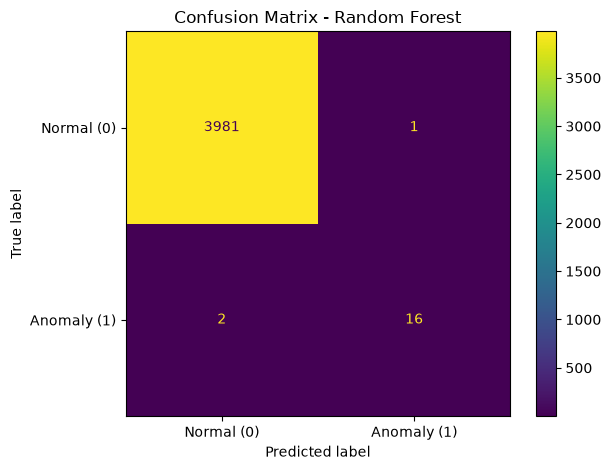

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal (0)", "Anomaly (1)"],
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal (0)", "Anomaly (1)"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()


### فحص الـ Overfitting

نقارن **F1 على Training** مع **F1 على Test**.

- فرق صغير → Generalization جيد.
- فرق كبير → احتمال Overfitting.
- Training F1 قريب جدًا من 1.00 مع Test F1 أقل بكثير → مؤشر قوي على Overfitting.

الـ `max_depth` و `min_samples_leaf` في الموديل الحالي تم وضعهما لتقليل تعقيد الأشجار.

In [46]:
y_train_pred = rf_model.predict(X_train)

train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
test_f1 = f1_score(y_test, y_pred, zero_division=0)
f1_gap = train_f1 - test_f1

print(f"Training F1: {train_f1:.4f}")
print(f"Test F1    : {test_f1:.4f}")
print(f"F1 Gap     : {f1_gap:.4f}")

if f1_gap <= 0.05:
    print("\nOverfitting check: No strong sign of overfitting.")
elif f1_gap <= 0.10:
    print("\nOverfitting check: Possible mild overfitting.")
else:
    print("\nOverfitting check: Strong sign of overfitting.")


Training F1: 0.9859
Test F1    : 0.9143
F1 Gap     : 0.0716

Overfitting check: Possible mild overfitting.


### Feature Importance

نستخرج أهم الخصائص التي استخدمها Random Forest في اتخاذ القرار.

**ملاحظة:** Feature Importance لا تثبت علاقة سببية، وارتفاع أهمية Feature وحده لا يثبت وجود Data Leakage.

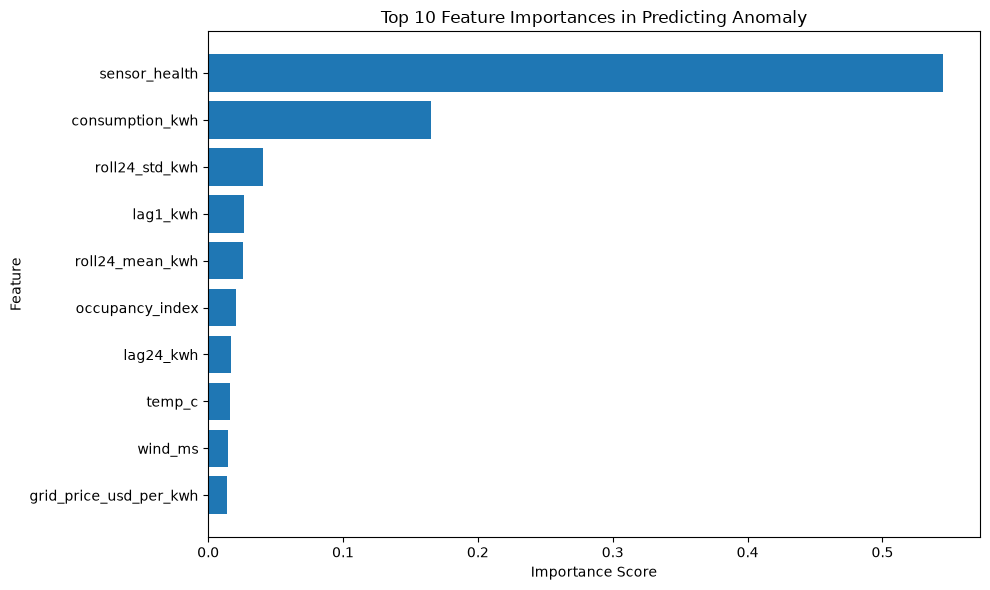

,Feature,Importance
21,sensor_health,0.545082
16,consumption_kwh,0.165450
20,roll24_std_kwh,0.040893
17,lag1_kwh,0.026496
19,roll24_mean_kwh,0.025750
14,occupancy_index,0.020857
18,lag24_kwh,0.016747
9,temp_c,0.016460
11,wind_ms,0.014557
13,grid_price_usd_per_kwh,0.013921


In [47]:
import pandas as pd

feature_imp_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

top_10_features = (
    feature_imp_df
    .sort_values(by="Importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_10_features["Feature"][::-1],
    top_10_features["Importance"][::-1]
)
plt.title("Top 10 Feature Importances in Predicting Anomaly")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(top_10_features)


# 21. XGBoost Classification

في المرحلة دي هنبدأ بناء موديل **XGBoost** لتصنيف استهلاك الطاقة إلى حالتين.

هنستخدم:

- **Target:** `high_usage_flag`
- `0` → Normal Usage
- `1` → High Usage

الموديل هيتعلم العلاقة بين الـ Features الموجودة في البيانات والـ Target، وبعد التدريب هيقدر يتوقع إذا كانت حالة الاستهلاك **High Usage** أو **Normal Usage**.

### هنمشي في الخطوات دي:

- تحديد الـ Target
- فصل الـ Features عن الـ Target
- تقسيم البيانات إلى **Training** و **Testing**
- إنشاء موديل **XGBClassifier**
- تدريب الموديل على بيانات التدريب
- عمل Predictions على بيانات الاختبار
- تقييم أداء الموديل باستخدام:
  - Accuracy
  - Precision
  - Recall
  - F1-Score
  - Confusion Matrix

الهدف هو بناء موديل قادر على تصنيف حالات **High Usage** بشكل جيد، مع الاهتمام خصوصًا بأداء الموديل في اكتشاف الفئة `1`.

Accuracy : 0.9815
Precision: 0.9381720430107527
Recall   : 0.8725
F1 Score : 0.9041450777202072

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3600
           1       0.94      0.87      0.90       400

    accuracy                           0.98      4000
   macro avg       0.96      0.93      0.95      4000
weighted avg       0.98      0.98      0.98      4000


Confusion Matrix:
[[3577   23]
 [  51  349]]


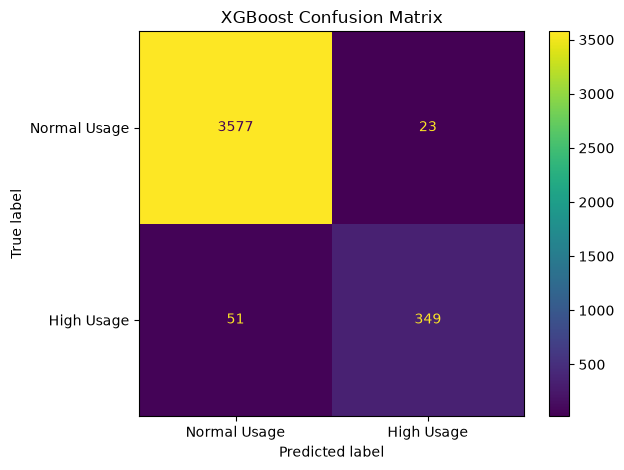

In [63]:
# ============================================
# 16. XGBoost Classification
# ============================================

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


# 1. Define Target
target = "high_usage_flag"


# 2. Split Features and Target
# Remove consumption_kwh to avoid target leakage
X = X_prepared.drop(
    columns=["high_usage_flag", "consumption_kwh"]
)

y = X_prepared["high_usage_flag"]


# 3. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# 4. Create XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)


# 5. Train the Model
xgb_model.fit(X_train, y_train)


# 6. Make Predictions
y_pred = xgb_model.predict(X_test)


# 7. Evaluate the Model
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


# 8. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# 9. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# 10. Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal Usage", "High Usage"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()